In [ ]:
Download - 2

In [2]:
import yfinance as yf
import pandas as pd

def download_market_sector_data():
    # 1. Varlıklar ve ilgili Sektör ETF'leri (Her sektör için 3 hisse)
    asset_map = {
        # Technology (XLK)
        'AAPL': 'XLK',
        'MSFT': 'XLK',
        'NVDA': 'XLK',
        
        # Consumer Discretionary (XLY)
        'TSLA': 'XLY',
        'AMZN': 'XLY',
        'HD':   'XLY',
        
        # Financials (XLF)
        'JPM':  'XLF',
        'BAC':  'XLF',
        'GS':   'XLF',
        
        # Energy (XLE)
        'XOM':  'XLE',
        'CVX':  'XLE',
        'COP':  'XLE',
        
        # Healthcare (XLV)
        'JNJ':  'XLV',
        'UNH':  'XLV',
        'PFE':  'XLV',
        
        # Consumer Staples (XLP)
        'WMT':  'XLP',
        'PG':   'XLP',
        'KO':   'XLP'
    }
    
    # 2. Piyasa Endeksleri (Benchmarklar)
    benchmarks = ['SPY', 'QQQ', 'DIA']
    
    # İndirilecek tüm benzersiz semboller
    all_tickers = list(asset_map.keys()) + list(set(asset_map.values())) + benchmarks
    
    print(f"Veriler indiriliyor: {len(all_tickers)} adet sembol...")
    
    # 3. 5 Yıllık günlük veriyi indir (Farklı piyasa rejimlerini yakalamak için)
    # yfinance'in yeni versiyonlarındaki format hatalarını önlemek için 'Close' alıyoruz
    data = yf.download(all_tickers, period="5y", interval="1d")['Close']
    
    # Eksik verileri doldur ve temizle
    data = data.ffill().dropna()
    
    # 4. Veriyi CSV olarak kaydet
    file_name = "market_sector_data.csv"
    data.to_csv(file_name)
    print(f"Başarılı! {len(data)} satır veri '{file_name}' dosyasına kaydedildi.")
    
    # Analiz adımı için sektör eşleştirme tablosunu kaydet
    mapping_df = pd.DataFrame(list(asset_map.items()), columns=['Stock', 'Sector_ETF'])
    mapping_df.to_csv("sector_mapping.csv", index=False)
    print("Sektör eşleştirme tablosu 'sector_mapping.csv' olarak kaydedildi.")

if __name__ == "__main__":
    download_market_sector_data()

Veriler indiriliyor: 27 adet sembol...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  27 of 27 completed


Başarılı! 1255 satır veri 'market_sector_data.csv' dosyasına kaydedildi.
Sektör eşleştirme tablosu 'sector_mapping.csv' olarak kaydedildi.


In [ ]:
Stage-3 faz-1-2

Loading data and initializing Phase 1 & 2...
Applying AR(1)-GARCH(1,1) filtering...
Executing EVT, L-Moments, and Risk Profiling...

PHASE 2: STATIC RISK & EVT PROFILE (5% and 1% Tail Indices)
| Stock   | Sector_ETF   |   VaR_95 |   Exp_Shortfall |   Std_Skew |   L_Skew |   Std_Kurt |   L_Kurt |   Tail_Idx_Right_5 |   Tail_Idx_Left_5 |   Tail_Asym_5 |   Tail_Idx_Right_1 |   Tail_Idx_Left_1 |   Tail_Asym_1 |
|:--------|:-------------|---------:|----------------:|-----------:|---------:|-----------:|---------:|-------------------:|------------------:|--------------:|-------------------:|------------------:|--------------:|
| AAPL    | XLK          |  -0.0278 |         -0.0408 |    -0.1223 |  -0.0154 |     3.0075 |   0.2054 |             3.0847 |            2.951  |        0.9566 |             2.8942 |            3.4102 |        1.1783 |
| MSFT    | XLK          |  -0.0273 |         -0.039  |     0.0623 |  -0.0182 |     5.7168 |   0.2018 |             2.9935 |            3.374  |        1

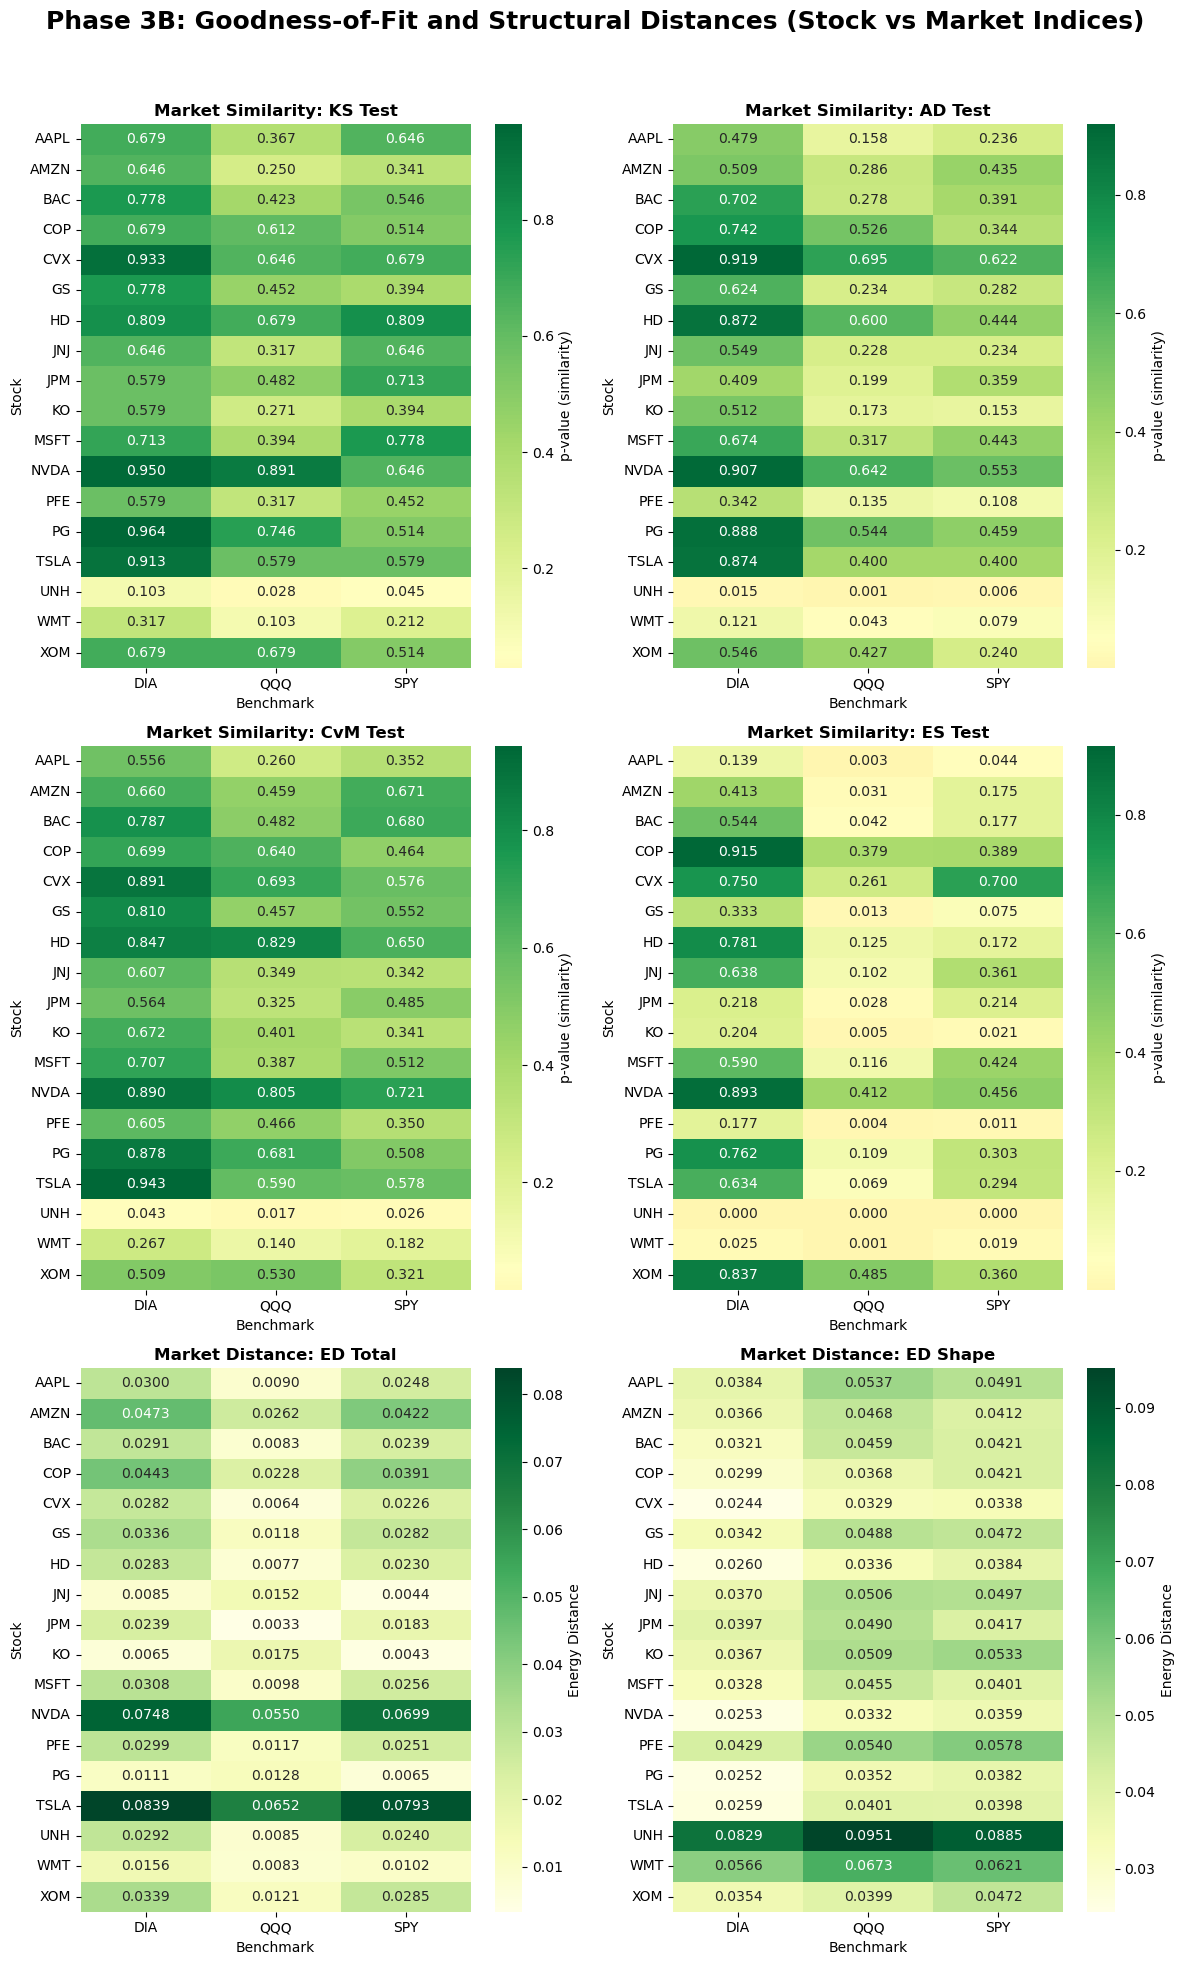

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from arch import arch_model
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# PHASE 1: ECONOMETRIC PREPROCESSING
# ==========================================

def apply_garch_filter(series):
    """AR(1)-GARCH(1,1) filter; başarısızsa Z-score fallback yapılmaz."""
    scaled = series * 100
    try:
        model = arch_model(scaled, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t')
        res = model.fit(disp='off', show_warning=False)
        if res.convergence_flag != 0: raise RuntimeError(f"Convergence flag={res.convergence_flag}")
        std_resid = res.std_resid.dropna()
        if len(std_resid) < 100 or not np.all(np.isfinite(std_resid)): raise RuntimeError("Invalid or insufficient residuals")
        return std_resid.values
    except Exception as e:
        raise RuntimeError(f"GARCH filtering failed for '{series.name}': {e}")
    
# ==========================================
# PHASE 2: STATIC RISK & EVT METRICS
# ==========================================

def calculate_l_moments(x):
    """Probability Weighted Moments (PWM) based L-Moments."""
    n = len(x)
    if n < 4: return np.nan, np.nan
    x_sorted = np.sort(x)
    i = np.arange(1, n + 1)
    b0 = np.mean(x_sorted)
    b1 = np.mean(x_sorted * ((i - 1) / (n - 1)))
    b2 = np.mean(x_sorted * ((i - 1) * (i - 2) / ((n - 1) * (n - 2))))
    b3 = np.mean(x_sorted * ((i - 1) * (i - 2) * (i - 3) / ((n - 1) * (n - 2) * (n - 3))))
    l1 = b0
    l2 = 2 * b1 - b0
    l3 = 6 * b2 - 6 * b1 + b0
    l4 = 20 * b3 - 30 * b2 + 12 * b1 - b0
    l_skewness = l3 / l2 if l2 > 0 else np.nan 
    l_kurtosis = l4 / l2 if l2 > 0 else np.nan 
    return l_skewness, l_kurtosis

def calculate_hill_estimator(data, threshold_percentile=95):
    """EVT based Hill Estimator for Right and Left Tails."""
    data = np.array(data)
    
    # Right Tail
    threshold_right = np.percentile(data, threshold_percentile)
    right_tail = data[data > threshold_right]
    gamma_right = np.mean(np.log(right_tail / threshold_right)) if (len(right_tail) > 1 and threshold_right > 0) else np.nan
    tail_idx_r = 1 / gamma_right if gamma_right > 0 else np.nan
    
    # Left Tail
    data_inv = -data
    threshold_left = np.percentile(data_inv, threshold_percentile)
    left_tail = data_inv[data_inv > threshold_left]
    gamma_left = np.mean(np.log(left_tail / threshold_left)) if (len(left_tail) > 1 and threshold_left > 0) else np.nan
    tail_idx_l = 1 / gamma_left if gamma_left > 0 else np.nan
    
    return tail_idx_r, tail_idx_l

def execute_phase1_and_2(data_path, mapping_path):
    print("Loading data and initializing Phase 1 & 2...")
    returns = pd.read_csv(data_path, index_col=0, parse_dates=True)
    returns = np.log(returns / returns.shift(1)).dropna()
    
    mapping = pd.read_csv(mapping_path)
    stocks = mapping['Stock'].tolist()
    benchmarks = ['SPY', 'QQQ', 'DIA']
    
    # 1. Apply AR(1)-GARCH(1,1) Filter
    filtered_residuals = {}
    print("Applying AR(1)-GARCH(1,1) filtering...")
    for ticker in returns.columns:
        filtered_residuals[ticker] = apply_garch_filter(returns[ticker])
        
    # 2. Calculate Static Risk and EVT
    print("Executing EVT, L-Moments, and Risk Profiling...")
    results = []
    
    for _, row in mapping.iterrows():
        stock = row['Stock']
        sector_etf = row['Sector_ETF']
        
        raw_ret = returns[stock].values
        z_scores = filtered_residuals[stock]
        
        if len(z_scores) < 100: continue
            
        # Economic Risk (Raw Returns)
        var_95 = np.percentile(raw_ret, 5)
        es_95 = raw_ret[raw_ret <= var_95].mean()
        
        # Structural Tail Risk (IID Residuals)
        std_skew = stats.skew(z_scores)
        std_kurt = stats.kurtosis(z_scores)
        l_skew, l_kurt = calculate_l_moments(z_scores)
        
        # 5% Tail Indices
        tail_idx_r_5, tail_idx_l_5 = calculate_hill_estimator(z_scores, 95)
        tail_asym_5 = tail_idx_l_5 / tail_idx_r_5 if (pd.notna(tail_idx_l_5) and pd.notna(tail_idx_r_5)) else np.nan
        
        # 1% Tail Indices
        tail_idx_r_1, tail_idx_l_1 = calculate_hill_estimator(z_scores, 99)
        tail_asym_1 = tail_idx_l_1 / tail_idx_r_1 if (pd.notna(tail_idx_l_1) and pd.notna(tail_idx_r_1)) else np.nan
        
        results.append({
            'Stock': stock,
            'Sector_ETF': sector_etf,
            'VaR_95': var_95,
            'Exp_Shortfall': es_95,
            'Std_Skew': std_skew,
            'L_Skew': l_skew,
            'Std_Kurt': std_kurt,
            'L_Kurt': l_kurt,
            'Tail_Idx_Right_5': tail_idx_r_5,
            'Tail_Idx_Left_5': tail_idx_l_5,
            'Tail_Asym_5': tail_asym_5,
            'Tail_Idx_Right_1': tail_idx_r_1,
            'Tail_Idx_Left_1': tail_idx_l_1,
            'Tail_Asym_1': tail_asym_1
        })
        
    df_static_risk = pd.DataFrame(results).round(4)
    print("\n" + "="*80)
    print("PHASE 2: STATIC RISK & EVT PROFILE (5% and 1% Tail Indices)")
    print("="*80)
    print(df_static_risk.to_markdown(index=False))
    
    return returns, filtered_residuals, df_static_risk, mapping

# ==========================================
# PHASE 3: COMPREHENSIVE & CONSISTENT GOF ANALYSIS
# ==========================================
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import numpy as np
import pandas as pd

def format_pvalue(p):
    """p-değerlerini akademik standartlara (yıldızlı ve <0.001) göre formatlar."""
    if pd.isna(p): return "NaN"
    if p < 0.001: return "<0.001***"
    elif p < 0.01: return f"{p:.3f}***"
    elif p < 0.05: return f"{p:.3f}**"
    elif p < 0.10: return f"{p:.3f}*"
    else: return f"{p:.3f}"

def calc_gof_metrics(s_raw, b_raw, s_garch, b_garch):
    """
    Standartlaştırma İPTAL EDİLMİŞTİR.
    ED_Total: Ham Getiriler
    GoF Testleri ve ED_Shape: Doğrudan GARCH Kalıntıları
    """
    # 1. En güncel tarihlerden geriye doğru hizalama
    min_len = min(len(s_garch), len(b_garch))
    s_std = s_garch[-min_len:]
    b_std = b_garch[-min_len:]
    s_raw_aligned = s_raw[-min_len:]
    b_raw_aligned = b_raw[-min_len:]
    
    # 2. Korelasyon ve Volatilite (Ham Getiriler)
    corr = np.corrcoef(s_raw_aligned, b_raw_aligned)[0, 1]
    ann_vol = (np.std(s_raw_aligned,ddof=1)*np.sqrt(252)
)
    
    # 3. Bağımsızlık (GARCH Kalıntıları)
    lb_p = acorr_ljungbox(s_std, lags=[10], return_df=True).iloc[0,1] if len(s_std) > 10 else np.nan
    jb_p = stats.jarque_bera(s_std)[1] # <--- YENİ EKLENDİ: Jarque-Bera p-değeri
        
    # 4. Dağılım Testleri (Doğrudan GARCH Kalıntıları)
    ks_p = stats.ks_2samp(s_std, b_std).pvalue
    cvm_p = stats.cramervonmises_2samp(s_std, b_std).pvalue
    
    try:
        ad_p = stats.anderson_ksamp([s_std, b_std], method=stats.PermutationMethod(n_resamples=1000, random_state=42)).pvalue
    except:
        ad_p = stats.anderson_ksamp([s_std, b_std]).pvalue
        
    try:
        es_p = stats.epps_singleton_2samp(s_std, b_std)[1]
    except:
        es_p = np.nan
        
    # 5. Energy Distance (Total: Ham, Shape: GARCH)
    ed_total = stats.energy_distance(s_raw_aligned, b_raw_aligned)
    ed_shape = stats.energy_distance(s_std, b_std)
    
    # <--- GÜNCELLENDİ: jb_p dönüş listesine 4. sıraya eklendi
    return corr, ann_vol, lb_p, jb_p, ks_p, ad_p, cvm_p, es_p, ed_total, ed_shape

def execute_phase3(returns, residuals, mapping, benchmarks=['SPY', 'QQQ', 'DIA']):
    print("Executing Phase 3: Structural Goodness-of-Fit Analysis...")
    results_sector = []
    results_market = []
    
    for _, row in mapping.iterrows():
        stock = row['Stock']
        sector_etf = row['Sector_ETF']
        
        s_raw = returns[stock].values
        s_res = residuals[stock]
        
        # A. Hisse vs Sektör ETF
        if sector_etf in returns.columns:
            sec_raw = returns[sector_etf].values
            sec_res = residuals[sector_etf]
            m_sec = calc_gof_metrics(s_raw, sec_raw, s_res, sec_res)
            results_sector.append({
                'Stock': stock, 'Sector': sector_etf, 
                'Corr': m_sec[0], 'Ann_Vol': m_sec[1], 'LB_p': m_sec[2],
                'JB_p': m_sec[3],  # <--- YENİ EKLENDİ
                'KS_p': m_sec[4], 'AD_p': m_sec[5], 'CvM_p': m_sec[6],  # <--- İNDEKSLER GÜNCELLENDİ
                'ES_p': m_sec[7], 'ED_Total': m_sec[8], 'ED_Shape': m_sec[9]
            })
        
        # B. Hisse vs Piyasa Endeksleri
        for bench in benchmarks:
            if bench in returns.columns:
                b_raw = returns[bench].values
                b_res = residuals[bench]
                m_mkt = calc_gof_metrics(s_raw, b_raw, s_res, b_res)
                results_market.append({
                    'Stock': stock, 'Benchmark': bench, 
                    'Corr': m_mkt[0], 'Ann_Vol': m_mkt[1], 'LB_p': m_mkt[2],
                    'JB_p': m_mkt[3],  # <--- YENİ EKLENDİ
                    'KS_p': m_mkt[4], 'AD_p': m_mkt[5], 'CvM_p': m_mkt[6],  # <--- İNDEKSLER GÜNCELLENDİ
                    'ES_p': m_mkt[7], 'ED_Total': m_mkt[8], 'ED_Shape': m_mkt[9]
                })
            
    df_sec = pd.DataFrame(results_sector)
    df_mkt = pd.DataFrame(results_market)
    
    # Tabloların kopyasını alalım (orijinal sayılar heatmap için bozulmasın)
    df_sec_display = df_sec.copy()
    df_mkt_display = df_mkt.copy()
    
    # Yıldızlanacak p-değeri sütunları
    p_cols = ['LB_p', 'JB_p', 'KS_p', 'AD_p', 'CvM_p', 'ES_p']
    
    for col in p_cols:
        df_sec_display[col] = df_sec_display[col].apply(format_pvalue)
        df_mkt_display[col] = df_mkt_display[col].apply(format_pvalue)
        
    # Diğer sayısal (korelasyon, volatilite, ED) sütunları yuvarlayalım
    num_cols = ['Corr', 'Ann_Vol', 'ED_Total', 'ED_Shape']
    df_sec_display[num_cols] = df_sec_display[num_cols].round(4)
    df_mkt_display[num_cols] = df_mkt_display[num_cols].round(4)

    print("\n" + "="*80)
    print("PHASE 3A: GOODNESS-OF-FIT (STOCK VS SECTOR)")
    print("="*80)
    print(df_sec_display.to_markdown(index=False))
    
    print("\n" + "="*80)
    print("PHASE 3B: GOODNESS-OF-FIT (STOCK VS MARKET)")
    print("="*80)
    print(df_mkt_display.to_markdown(index=False))
    
    # ---- GÖRSELLEŞTİRME: Heatmap for Market (Phase 3B) ----
    import matplotlib.pyplot as plt
    import seaborn as sns

    plot_cols = ['KS_p', 'AD_p', 'CvM_p', 'ES_p', 'ED_Total', 'ED_Shape']
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 20))
    axes = axes.flatten()
    
    for i, col in enumerate(plot_cols):
        pivot_df = df_mkt.pivot(index='Stock', columns='Benchmark', values=col)
        
        if col.endswith('_p'):
            # P-değerleri: Orijinal yapıyı (0.05 merkezli sarı/yeşil geçişini) koruyoruz
            sns.heatmap(pivot_df, annot=True, cmap='RdYlGn', center=0.05, fmt='.3f', 
                        cbar_kws={'label': 'p-value (similarity)'}, ax=axes[i])
            axes[i].set_title(f'Market Similarity: {col.replace("_p", "")} Test', fontsize=12, fontweight='bold')
        else:
            # Energy Distance: En düşük değer sapsarı, en yüksek değer yemyeşil (YlGn paleti)
            sns.heatmap(pivot_df, annot=True, cmap='YlGn', fmt='.4f', 
                        cbar_kws={'label': 'Energy Distance'}, ax=axes[i])
            axes[i].set_title(f'Market Distance: {col.replace("_", " ")}', fontsize=12, fontweight='bold')
            
        axes[i].set_xlabel('Benchmark')
        axes[i].set_ylabel('Stock')
    
    plt.suptitle('Phase 3B: Goodness-of-Fit and Structural Distances (Stock vs Market Indices)', fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('phase3b_market_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return df_sec, df_mkt

# Run the first three phases
if __name__ == "__main__":

    # Faz 1&2:
    returns, residuals, df_static, mapping = execute_phase1_and_2("market_sector_data.csv", "sector_mapping.csv")
    # Faz 3: Yapısal Uyum Testleri (Hisse-Sektör ve Hisse-Piyasa Endeksleri)
    df_phase3_sec, df_phase3_mkt = execute_phase3(returns=returns,residuals=residuals,mapping=mapping,benchmarks=['SPY', 'QQQ', 'DIA'])
    

In [ ]:
faz-4 


PHASE 4: ROLLING TAIL SIMILARITY (TECHNOLOGY SECTOR)


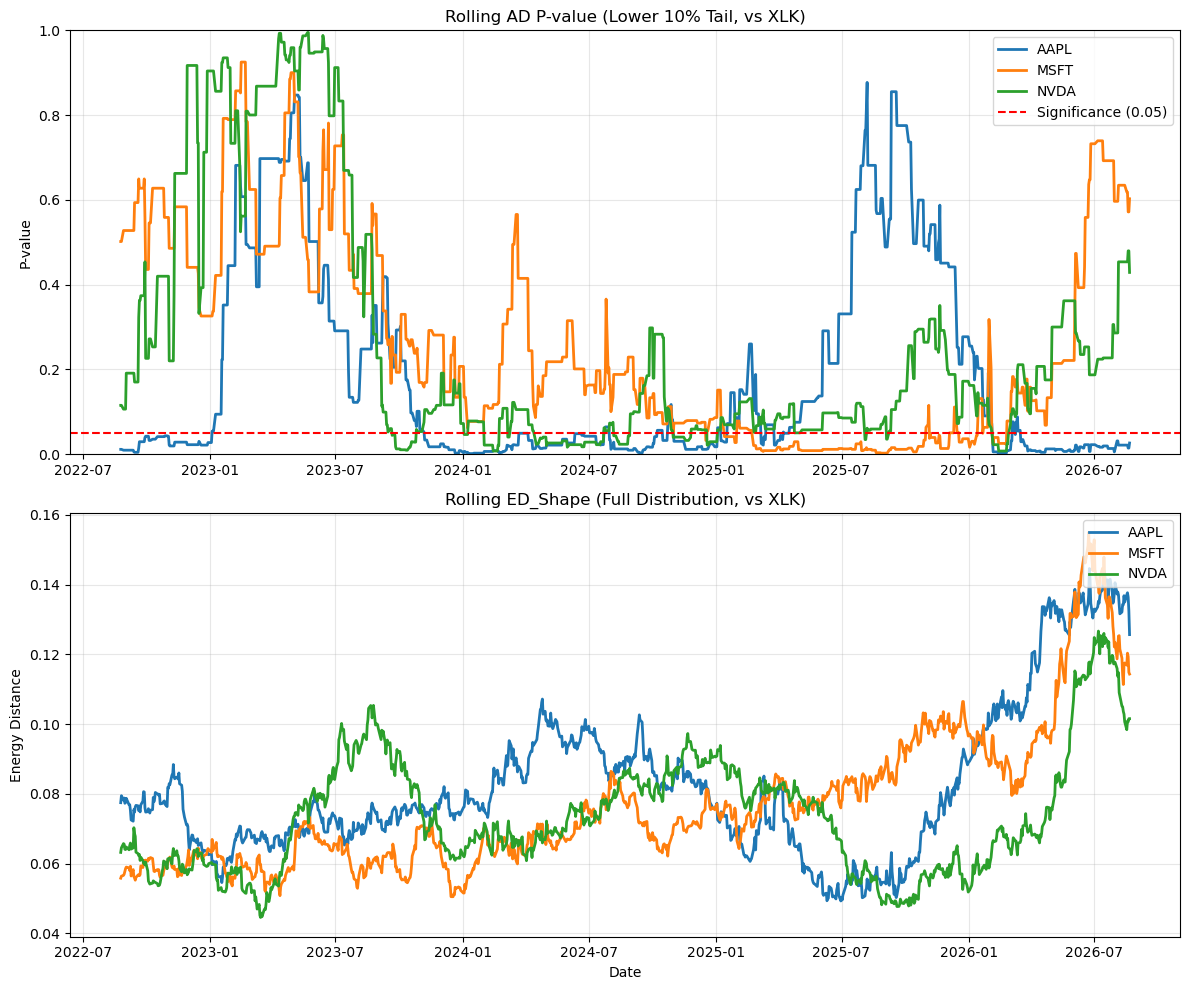


Rolling Summary (Stock vs Sector ETF):
| Stock   | Sector   |   Corr |   AD_Mean |   AD_Std |   ED_Mean |   ED_Std |
|:--------|:---------|-------:|----------:|---------:|----------:|---------:|
| AAPL    | XLK      | 0.6873 |    0.1846 |   0.2383 |    0.0821 |   0.0215 |
| MSFT    | XLK      | 0.7215 |    0.2611 |   0.2439 |    0.0767 |   0.0203 |
| NVDA    | XLK      | 0.8035 |    0.2597 |   0.2916 |    0.0735 |   0.0166 |
| TSLA    | XLY      | 0.7678 |    0.1708 |   0.2397 |    0.0776 |   0.0184 |
| AMZN    | XLY      | 0.7939 |    0.2319 |   0.2775 |    0.0686 |   0.0144 |
| HD      | XLY      | 0.6305 |    0.257  |   0.2566 |    0.0753 |   0.0173 |
| JPM     | XLF      | 0.8451 |    0.3437 |   0.3207 |    0.0662 |   0.0191 |
| BAC     | XLF      | 0.8476 |    0.2353 |   0.2475 |    0.0699 |   0.0134 |
| GS      | XLF      | 0.7767 |    0.175  |   0.2431 |    0.0815 |   0.0187 |
| XOM     | XLE      | 0.9245 |    0.3934 |   0.3252 |    0.0554 |   0.0113 |
| CVX     | XLE      | 0

In [2]:
# ==========================================
# PHASE 4: ROLLING TAIL SIMILARITY (SECTOR-BASED)
# ==========================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

def rolling_tail_ad_test(s_garch, b_garch, window=252, n_resamples=1000):
    """
    Rolling Anderson-Darling test on the LOWER 10% tail of GARCH residuals.
    - No extra standardization (GARCH residuals are already standardized).
    - Extracts only the left tail (values <= 10th percentile).
    """
    sims = []
    for i in range(window, len(s_garch)):
        w1 = s_garch[i-window:i]
        w2 = b_garch[i-window:i]
        
        # Sol %10 kuyruğu kes (doğrudan GARCH kalıntıları üzerinden)
        q1 = np.quantile(w1, 0.10)
        q2 = np.quantile(w2, 0.10)
        t1 = w1[w1 <= q1]
        t2 = w2[w2 <= q2]
        
        if len(t1) < 10 or len(t2) < 10:
            sims.append(np.nan)
            continue
        try:
            res = stats.anderson_ksamp([t1, t2],
                                       method=stats.PermutationMethod(n_resamples=n_resamples, random_state=42))
            sims.append(res.pvalue)
        except:
            sims.append(np.nan)
    return pd.Series(sims)

def rolling_ed_shape(s_garch, b_garch, window=252):
    """
    Rolling Energy Distance (shape) using GARCH residuals directly.
    No quantile, no extra standardization.
    """
    sims = []
    for i in range(window, len(s_garch)):
        w1 = s_garch[i-window:i]
        w2 = b_garch[i-window:i]
        ed = stats.energy_distance(w1, w2)
        sims.append(ed)
    return pd.Series(sims)

def run_phase4_rolling_analysis(returns, residuals, mapping, window=252):
    """
    Phase 4: Rolling tail similarity for Technology sector (XLK) with 3 stocks.
    - Plot 1: Rolling AD p-value (GARCH residuals, lower 10% tail)
    - Plot 2: Rolling ED_Shape (GARCH residuals, full distribution)
    - Summary table for all stocks: Corr (static), mean/std of AD_p and ED_Shape.
    """
    print("\n" + "="*80)
    print("PHASE 4: ROLLING TAIL SIMILARITY (TECHNOLOGY SECTOR)")
    print("="*80)
    
    stocks = mapping['Stock'].tolist()
    sector_dict = dict(zip(mapping['Stock'], mapping['Sector_ETF']))
    
    # Selected sector and stocks for visualization
    selected_sector = 'XLK'
    selected_stocks = ['AAPL', 'MSFT', 'NVDA']  # Technology stocks
    
    # ---- 1. Compute rolling data for ALL stocks (vs their sector) ----
    rolling_ad_dict = {}
    rolling_ed_dict = {}
    
    for stock in stocks:
        sector = sector_dict[stock]
        if sector not in returns.columns or stock not in returns.columns:
            continue
        
        # GARCH residuals for both AD (tail) and ED_Shape (full)
        s_garch = residuals[stock]
        b_garch = residuals[sector]
        min_len = min(len(s_garch), len(b_garch))
        
        # Rolling AD (lower 10% tail)
        ad_ser = rolling_tail_ad_test(s_garch[-min_len:], b_garch[-min_len:], window=window)
        rolling_ad_dict[stock] = ad_ser
        
        # Rolling ED_Shape (full distribution)
        ed_ser = rolling_ed_shape(s_garch[-min_len:], b_garch[-min_len:], window=window)
        rolling_ed_dict[stock] = ed_ser
    
    rolling_ad_df = pd.DataFrame(rolling_ad_dict)
    rolling_ed_df = pd.DataFrame(rolling_ed_dict)
    rolling_ad_df.index = returns.index[-len(rolling_ad_df):]
    rolling_ed_df.index = returns.index[-len(rolling_ed_df):]
    
    # ---- 2. Plot: 2 subplots (AD and ED_Shape) for selected sector ----
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Subplot 1: AD p-value (lower tail)
    ax1 = axes[0]
    for stock in selected_stocks:
        if stock in rolling_ad_df.columns:
            ax1.plot(rolling_ad_df.index, rolling_ad_df[stock], label=stock, linewidth=2)
    ax1.axhline(y=0.05, color='red', linestyle='--', label='Significance (0.05)')
    ax1.set_title(f'Rolling AD P-value (Lower 10% Tail, vs {selected_sector})', fontsize=12)
    ax1.set_ylabel('P-value')
    ax1.legend(loc='upper right')
    ax1.grid(alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # Subplot 2: ED_Shape
    ax2 = axes[1]
    for stock in selected_stocks:
        if stock in rolling_ed_df.columns:
            ax2.plot(rolling_ed_df.index, rolling_ed_df[stock], label=stock, linewidth=2)
    ax2.set_title(f'Rolling ED_Shape (Full Distribution, vs {selected_sector})', fontsize=12)
    ax2.set_ylabel('Energy Distance')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper right')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('phase4_rolling_tech_sector.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    summary_list = []
    for stock in stocks:
        sector = sector_dict[stock]
        if sector not in returns.columns or stock not in returns.columns:
            continue
        
        # Static Corr (Phase 3 method)
        s_raw = returns[stock].values
        b_raw = returns[sector].values
        s_garch = residuals[stock]
        b_garch = residuals[sector]
        corr, _, _, _, _, _, _, _, _, _ = calc_gof_metrics(s_raw, b_raw, s_garch, b_garch)
        
        # Rolling AD stats
        ad_ser = rolling_ad_df[stock].dropna()
        if len(ad_ser) == 0:
            ad_mean, ad_std = np.nan, np.nan
        else:
            ad_mean, ad_std = ad_ser.mean(), ad_ser.std()
        
        # Rolling ED stats
        ed_ser = rolling_ed_df[stock].dropna()
        if len(ed_ser) == 0:
            ed_mean, ed_std = np.nan, np.nan
        else:
            ed_mean, ed_std = ed_ser.mean(), ed_ser.std()
        
        summary_list.append({
            'Stock': stock,
            'Sector': sector,
            'Corr': corr,
            'AD_Mean': ad_mean,
            'AD_Std': ad_std,
            'ED_Mean': ed_mean,
            'ED_Std': ed_std
        })
    
    summary_df = pd.DataFrame(summary_list).round(4)
    
    print("\nRolling Summary (Stock vs Sector ETF):")
    print(summary_df.to_markdown(index=False))
    
    # Save to CSV
    summary_df.to_csv("phase4_rolling_summary.csv", index=False)
    rolling_ad_df.to_csv("phase4_rolling_ad_pvalues.csv")
    rolling_ed_df.to_csv("phase4_rolling_ed_shape.csv")
    
    return rolling_ad_df, rolling_ed_df, summary_df

# ==========================================
# ÇALIŞTIRMA BLOĞU (TEST)
# ==========================================
if __name__ == "__main__":
    # returns, residuals ve mapping değişkenlerinin Faz 1-3'ten başarıyla aktarıldığını varsayıyoruz.
    # Phase 4
    rolling_ad, rolling_ed, summary = run_phase4_rolling_analysis(returns, residuals, mapping, window=252)

In [ ]:
faz-5 


PHASE 5: HIERARCHICAL CLUSTERING & SILHOUETTE VALIDATION

Silhouette Validation:
|   Clusters |   Silhouette_Score |
|-----------:|-------------------:|
|          2 |           0.661917 |
|          3 |           0.443117 |
|          4 |           0.389018 |
|          5 |           0.31843  |

Best number of clusters based on Silhouette score: 2 (score: 0.6619)
Using user-specified clusters: 3

Average Silhouette Score for 3 clusters: 0.4431
(Score ranges from -1 to 1; higher values indicate better clustering)


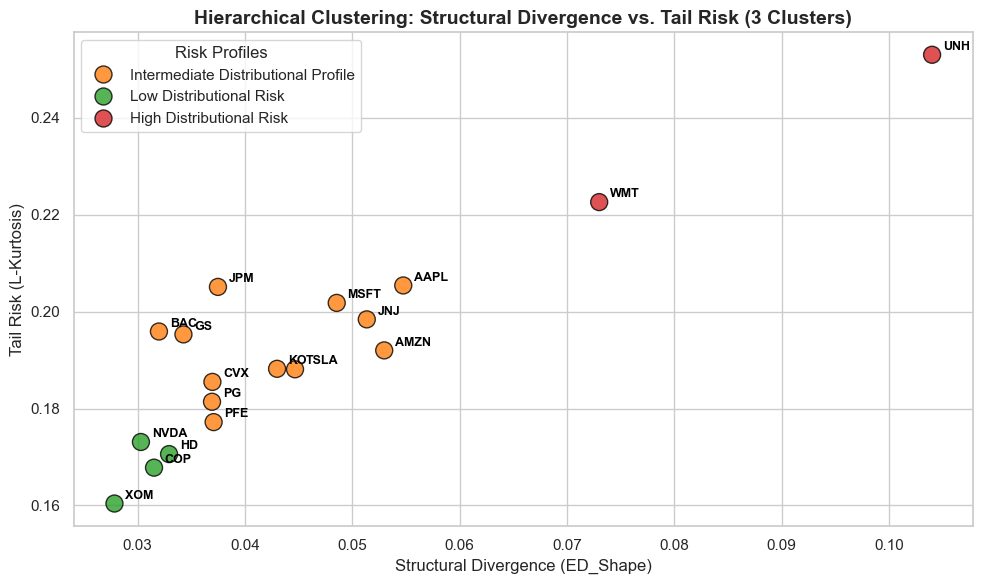


Cluster Summary for 3 clusters (mean values):
        ED_Shape          L_Kurt         Silhouette                
            mean     std    mean     std       mean     min     max
Cluster                                                            
0         0.0885  0.0219  0.2378  0.0215     0.2441 -0.0083  0.4965
1         0.0425  0.0078  0.1929  0.0091     0.3781 -0.4046  0.6044
2         0.0307  0.0022  0.1680  0.0055     0.7378  0.6947  0.7997

Detailed Cluster Assignment (3 clusters):
| Stock   |   ED_Shape |   L_Kurt |   Cluster | Profile                             |   Silhouette |
|:--------|-----------:|---------:|----------:|:------------------------------------|-------------:|
| AAPL    |  0.0547493 |   0.2054 |         1 | Intermediate Distributional Profile |   0.543019   |
| MSFT    |  0.0485502 |   0.2018 |         1 | Intermediate Distributional Profile |   0.604368   |
| NVDA    |  0.0303078 |   0.1731 |         2 | Low Distributional Risk             |   0.694713  

In [3]:
# ==========================================
# PHASE 5: HIERARCHICAL CLUSTERING & SILHOUETTE VALIDATION (OPTIMIZED)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

def run_phase5_clustering(df_phase3_sec, df_static, mapping, n_clusters=3):
    """
    Phase 5: Hierarchical clustering using ED_Shape (structural divergence)
    and L_Kurtosis (tail heaviness). Computes Silhouette scores for 2-5 clusters,
    selects the best based on score, and plots scatter plot with risk profiles.
    
    Parameters:
    - df_phase3_sec: DataFrame from Phase 3 (stock vs sector) with columns: Stock, ED_Shape, etc.
    - df_static: DataFrame from Phase 2 with columns: Stock, L_Kurt, etc.
    - mapping: DataFrame with Stock and Sector_ETF columns.
    - n_clusters: desired number of clusters (default 3), but will evaluate 2-5 and print table.
    
    Returns:
    - cluster_df: DataFrame with Stock, ED_Shape, L_Kurt, Cluster, Silhouette, Profile.
    - silhouette_df: DataFrame with cluster counts and silhouette scores for 2-5.
    """
    print("\n" + "="*80)
    print("PHASE 5: HIERARCHICAL CLUSTERING & SILHOUETTE VALIDATION")
    print("="*80)
    
    # 1. Verileri birleştir
    df_ed = df_phase3_sec[['Stock', 'ED_Shape']].copy()
    df_ed['ED_Shape'] = df_ed['ED_Shape'].astype(float)
    
    df_evt = df_static[['Stock', 'L_Kurt']].copy()
    df_evt['L_Kurt'] = df_evt['L_Kurt'].astype(float)
    
    cluster_df = pd.merge(df_ed, df_evt, on='Stock')
    
    if cluster_df.isnull().any().any():
        print("Warning: Missing values found. Dropping rows with NaN.")
        cluster_df = cluster_df.dropna()
    
    X = cluster_df[['ED_Shape', 'L_Kurt']].values
    
    # 2. Silhouette skorlarını 2-5 küme için hesapla
    cluster_range = range(2, 6)
    sil_scores = []
    for k in cluster_range:
        hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
        labels = hc.fit_predict(X)
        score = silhouette_score(X, labels, metric='euclidean')
        sil_scores.append(score)
    
    silhouette_df = pd.DataFrame({
        'Clusters': list(cluster_range),
        'Silhouette_Score': sil_scores
    })
    
    print("\nSilhouette Validation:")
    print(silhouette_df.to_markdown(index=False))
    
    # 3. En iyi küme sayısını seç (en yüksek siluet skoru)
    best_k = silhouette_df.loc[silhouette_df['Silhouette_Score'].idxmax(), 'Clusters']
    print(f"\nBest number of clusters based on Silhouette score: {best_k} (score: {silhouette_df['Silhouette_Score'].max():.4f})")
    
    # 4. İstenen küme sayısı ile (n_clusters) veya en iyi ile devam et
    # Kullanıcının verdiği n_clusters'ı kullan, ancak en iyi skoru da göster
    final_k = n_clusters
    print(f"Using user-specified clusters: {final_k}")
    
    # 5. Final kümeleme
    hc_final = AgglomerativeClustering(
        n_clusters=final_k,
        metric='euclidean',
        linkage='ward'
    )
    cluster_labels = hc_final.fit_predict(X)
    cluster_df['Cluster'] = cluster_labels
    
    # 6. Silhouette skorları (genel ve örnek bazlı)
    sil_avg = silhouette_score(X, cluster_labels, metric='euclidean')
    sil_samples = silhouette_samples(X, cluster_labels, metric='euclidean')
    cluster_df['Silhouette'] = sil_samples
    
    print(f"\nAverage Silhouette Score for {final_k} clusters: {sil_avg:.4f}")
    print("(Score ranges from -1 to 1; higher values indicate better clustering)")
    
    # 7. Küme merkezleri ve risk profili etiketleme (3 küme için varsayılan)
    # Eğer final_k 3 değilse, genel bir etiketleme yapalım
    centers = cluster_df.groupby('Cluster')[['ED_Shape', 'L_Kurt']].mean()
    risk_scores = centers.sum(axis=1)
    sorted_clusters = risk_scores.sort_values().index
    
    if final_k == 3:
        cluster_mapping = {
            sorted_clusters[0]: 'Low Distributional Risk',
            sorted_clusters[1]: 'Intermediate Distributional Profile',
            sorted_clusters[2]: 'High Distributional Risk'
        }
    elif final_k == 2:
        cluster_mapping = {
            sorted_clusters[0]: 'Low Risk',
            sorted_clusters[1]: 'High Risk'
        }
    else:
        # 4 veya 5 küme için genel etiket
        cluster_mapping = {}
        for i, cluster_id in enumerate(sorted_clusters):
            if i == 0:
                cluster_mapping[cluster_id] = f'Risk Level {i+1} (Lowest)'
            elif i == len(sorted_clusters)-1:
                cluster_mapping[cluster_id] = f'Risk Level {i+1} (Highest)'
            else:
                cluster_mapping[cluster_id] = f'Risk Level {i+1}'
    
    cluster_df['Profile'] = cluster_df['Cluster'].map(cluster_mapping)
    
    # 8. Görselleştirme (Scatter Plot)
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Renk paleti (küme sayısına göre)
    if final_k == 3:
        palette = {
            'Low Distributional Risk': '#2ca02c',
            'Intermediate Distributional Profile': '#ff7f0e',
            'High Distributional Risk': '#d62728'
        }
    else:
        # Genel renk paleti
        unique_profiles = cluster_df['Profile'].unique()
        colors = sns.color_palette("husl", len(unique_profiles))
        palette = {profile: colors[i] for i, profile in enumerate(unique_profiles)}
    
    ax = sns.scatterplot(
        data=cluster_df,
        x='ED_Shape',
        y='L_Kurt',
        hue='Profile',
        palette=palette,
        s=150,
        edgecolor='black',
        alpha=0.8
    )
    
    # Hisse isimlerini etiketle
    for i, row in cluster_df.iterrows():
        plt.text(
            row['ED_Shape'] + 0.001,
            row['L_Kurt'] + 0.001,
            row['Stock'],
            fontsize=9,
            weight='bold',
            color='black'
        )
    
    plt.title(f'Hierarchical Clustering: Structural Divergence vs. Tail Risk ({final_k} Clusters)', fontsize=14, fontweight='bold')
    plt.xlabel('Structural Divergence (ED_Shape)', fontsize=12)
    plt.ylabel('Tail Risk (L-Kurtosis)', fontsize=12)
    plt.legend(title='Risk Profiles', loc='upper left')
    
    plt.tight_layout()
    plt.savefig(f'phase5_clustering_{final_k}clusters.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 9. Küme özet tablosu
    print(f"\nCluster Summary for {final_k} clusters (mean values):")
    cluster_summary = cluster_df.groupby('Cluster').agg({
        'ED_Shape': ['mean', 'std'],
        'L_Kurt': ['mean', 'std'],
        'Silhouette': ['mean', 'min', 'max']
    }).round(4)
    print(cluster_summary)
    
    # 10. Detaylı tablo
    print(f"\nDetailed Cluster Assignment ({final_k} clusters):")
    print(cluster_df[['Stock', 'ED_Shape', 'L_Kurt', 'Cluster', 'Profile', 'Silhouette']].to_markdown(index=False))
    
    # CSV olarak kaydet
    cluster_df.to_csv(f"phase5_clustering_{final_k}clusters.csv", index=False)
    silhouette_df.to_csv("phase5_silhouette_validation.csv", index=False)
    
    return cluster_df, silhouette_df

# ==========================================
# ÇALIŞTIRMA BLOĞU (ÖRNEK)
# ==========================================
if __name__ == "__main__":
    # Phase 5: Clustering with silhouette validation table
    cluster_df, silhouette_df = run_phase5_clustering(
        df_phase3_sec=df_phase3_sec,   # Phase 3'ten gelen sektör karşılaştırma tablosu
        df_static=df_static,           # Phase 2'den gelen statik risk/EVT tablosu
        mapping=mapping,
        n_clusters=3                   # İstenen küme sayısı (önerilen 3)
    )

In [ ]:
faz-6-in-sample-simulation


PHASE 6: MONTE CARLO RANDOM PORTFOLIO BENCHMARK IN-SAMPLE (8 MODELS)
Random Portfolios Mean Sharpe : 1.105
--------------------------------------------------------------------------------
ED Only                             -> Sharpe: 1.2183 (Beats 79.2%) | ES: -2.36%
ED + KS                             -> Sharpe: 1.2680 (Beats 89.0%) | ES: -2.47%
ED + KS + L-Kurt                    -> Sharpe: 1.2824 (Beats 90.9%) | ES: -2.47%
ED + KS + Tail_Asym                 -> Sharpe: 1.2408 (Beats 84.8%) | ES: -2.55%
ED + AD + Tail_Asym                 -> Sharpe: 1.2580 (Beats 87.6%) | ES: -2.59%
ED + AD + L-Kurt                    -> Sharpe: 1.2998 (Beats 93.2%) | ES: -2.51%
ED + CvM + Tail_Asym                -> Sharpe: 1.2231 (Beats 80.9%) | ES: -2.61%
ED + Epps-Singleton + Tail_Asym     -> Sharpe: 1.4004 (Beats 98.6%) | ES: -2.83%
*Lower Expected Shortfall = better tail-risk protection.


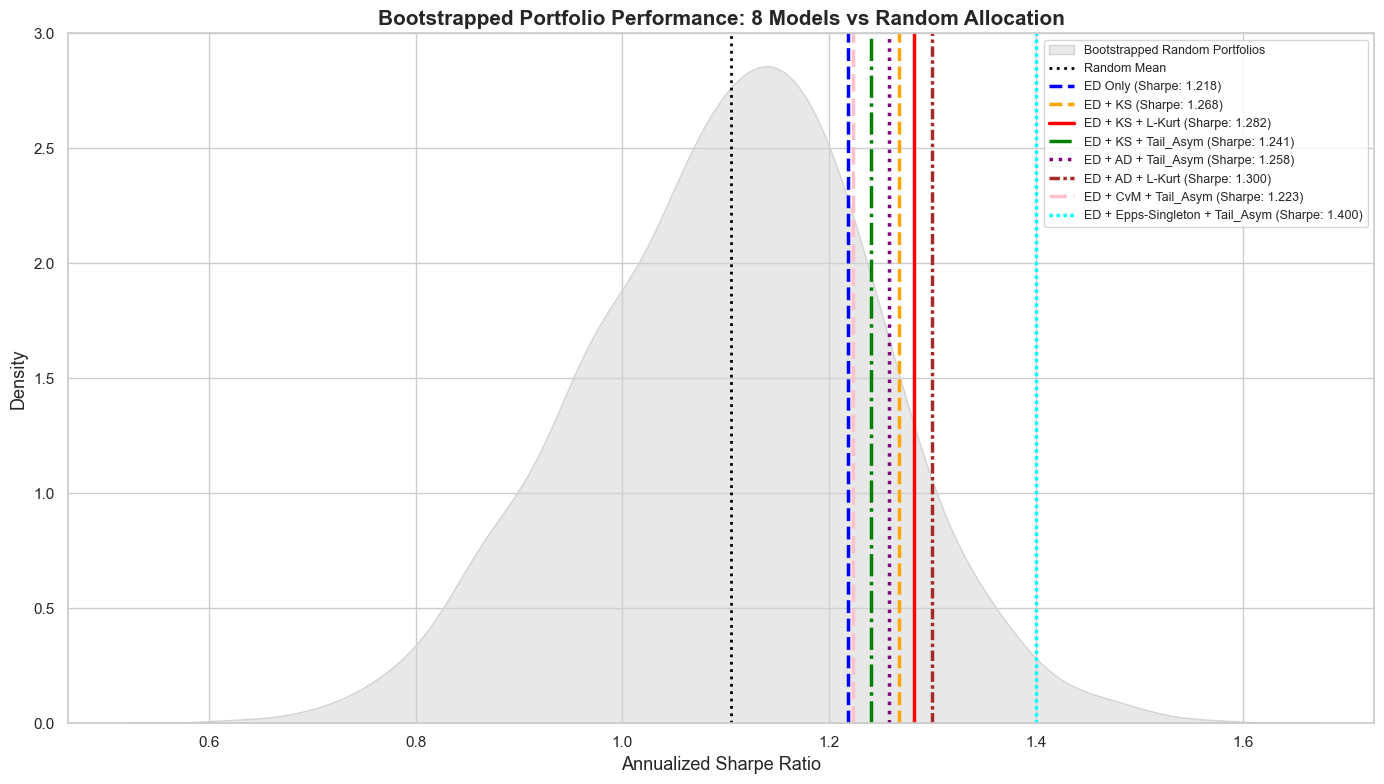


Summary Table (8 Models):
| Model                           |   Sharpe |   Beat_Rate_% |   Expected_Shortfall_% |
|:--------------------------------|---------:|--------------:|-----------------------:|
| ED Only                         |   1.2183 |          79.2 |                -2.3583 |
| ED + KS                         |   1.268  |          89   |                -2.4657 |
| ED + KS + L-Kurt                |   1.2824 |          90.9 |                -2.4688 |
| ED + KS + Tail_Asym             |   1.2408 |          84.8 |                -2.55   |
| ED + AD + Tail_Asym             |   1.258  |          87.6 |                -2.5883 |
| ED + AD + L-Kurt                |   1.2998 |          93.2 |                -2.5081 |
| ED + CvM + Tail_Asym            |   1.2231 |          80.9 |                -2.6109 |
| ED + Epps-Singleton + Tail_Asym |   1.4004 |          98.6 |                -2.8285 |


In [4]:
# ==========================================
# PHASE 6: MONTE CARLO RANDOM PORTFOLIO BENCHMARK IN-SAMPLE (8 MODELS)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def run_phase6_bootstrapped_backtest(returns_df, df_phase3_sec, df_static, num_portfolios=1000):
    """
    Phase 6: Bootstrapped portfolio simulation with 8 selected models.
    Models:
      1. ED Only
      2. ED + KS
      3. ED + KS + L-Kurtosis
      4. ED + KS + Tail_Asym
      5. ED + AD + Tail_Asym
      6. ED + AD + L-Kurtosis
      7. ED + CvM + Tail_Asym
      8. ED + Epps-Singleton + Tail_Asym
    """
    print("\n" + "="*80)
    print("PHASE 6: MONTE CARLO RANDOM PORTFOLIO BENCHMARK IN-SAMPLE (8 MODELS)")
    print("="*80)
    
    # ---- 1. Veri Hazırlığı ----
    stocks = df_phase3_sec['Stock'].tolist()
    stock_returns = returns_df[stocks].copy()
    # Logaritmik getirileri basit getiriye (exp(r) - 1) dönüştürüyoruz
    stock_returns = np.exp(stock_returns[stocks].copy()) - 1
    
    # Metrikleri çek (raw)
    ed_values = df_phase3_sec.set_index('Stock')['ED_Shape'].astype(float).loc[stocks].values
    ks_p_values = df_phase3_sec.set_index('Stock')['KS_p'].astype(float).loc[stocks].values
    ad_p_values = df_phase3_sec.set_index('Stock')['AD_p'].astype(float).loc[stocks].values
    cvm_p_values = df_phase3_sec.set_index('Stock')['CvM_p'].astype(float).loc[stocks].values
    es_p_values = df_phase3_sec.set_index('Stock')['ES_p'].astype(float).loc[stocks].values
    l_kurt_values = df_static.set_index('Stock')['L_Kurt'].astype(float).loc[stocks].values
    tail_asym_values = df_static.set_index('Stock')['Tail_Asym_5'].astype(float).loc[stocks].values
    
    # ---- 2. Model Ağırlıkları ----
    # Model 1: ED Only
    w1 = 1.0 / ed_values
    w1 = w1 / np.sum(w1)
    
    # Model 2: ED + KS
    w2 = (1.0 / ed_values) * (ks_p_values + 0.001)
    w2 = w2 / np.sum(w2)
    
    # Model 3: ED + KS + L-Kurt
    w3 = ((1.0 / ed_values) * (ks_p_values + 0.001)) / l_kurt_values
    w3 = w3 / np.sum(w3)
    
    # Model 4: ED + KS + Tail_Asym
    w4 = ((1.0 / ed_values) * (ks_p_values + 0.001)) * tail_asym_values
    w4 = w4 / np.sum(w4)
    
    # Model 5: ED + AD + Tail_Asym
    w5 = ((1.0 / ed_values) * (ad_p_values + 0.001)) * tail_asym_values
    w5 = w5 / np.sum(w5)
    
    # Model 6: ED + AD + L-Kurt
    w6 = ((1.0 / ed_values) * (ad_p_values + 0.001)) / l_kurt_values
    w6 = w6 / np.sum(w6)
    
    # Model 7: ED + CvM + Tail_Asym
    w7 = ((1.0 / ed_values) * (cvm_p_values + 0.001)) * tail_asym_values
    w7 = w7 / np.sum(w7)
    
    # Model 8: ED + Epps-Singleton + Tail_Asym
    w8 = ((1.0 / ed_values) * (es_p_values + 0.001)) * tail_asym_values
    w8 = w8 / np.sum(w8)
    
    weights_list = [w1, w2, w3, w4, w5, w6, w7, w8]
    model_names = [
        'ED Only',
        'ED + KS',
        'ED + KS + L-Kurt',
        'ED + KS + Tail_Asym',
        'ED + AD + Tail_Asym',
        'ED + AD + L-Kurt',
        'ED + CvM + Tail_Asym',
        'ED + Epps-Singleton + Tail_Asym'
    ]
    
    # ---- 3. Performans Fonksiyonları ----
    def calc_sharpe(weights):
        port_ret = stock_returns.dot(weights)
        return (port_ret.mean() / port_ret.std()) * np.sqrt(252)
    
    def calc_expected_shortfall(weights, confidence_level=0.05):
        port_ret = stock_returns.dot(weights)
        threshold = np.percentile(port_ret, confidence_level * 100)
        cvar = port_ret[port_ret <= threshold].mean()
        return cvar * 100
    
    # ---- 4. Bootstrapping ----
    np.random.seed(42)
    random_sharpes = []
    for _ in range(num_portfolios):
        rand_w = np.random.dirichlet(np.ones(len(stocks)))
        random_sharpes.append(calc_sharpe(rand_w))
    random_sharpes = np.array(random_sharpes)
    random_mean = random_sharpes.mean()
    
    # ---- 5. Model Performansları ----
    results = []
    for name, w in zip(model_names, weights_list):
        sharpe = calc_sharpe(w)
        es = calc_expected_shortfall(w)
        beat = np.sum(sharpe > random_sharpes) / num_portfolios * 100
        results.append({'Model': name, 'Sharpe': sharpe, 'Beat_Rate_%': beat, 'Expected_Shortfall_%': es})
    
    results_df = pd.DataFrame(results).round(4)
    
    # ---- 6. Raporlama ----
    print(f"Random Portfolios Mean Sharpe : {random_mean:.3f}")
    print("-" * 80)
    for _, row in results_df.iterrows():
        print(f"{row['Model']:35} -> Sharpe: {row['Sharpe']:.4f} (Beats {row['Beat_Rate_%']:.1f}%) | ES: {row['Expected_Shortfall_%']:.2f}%")
    print("*Lower Expected Shortfall = better tail-risk protection.")
    
    # ---- 7. Görselleştirme (Tüm 8 Model) ----
    plt.figure(figsize=(14, 8))
    sns.set_theme(style="whitegrid")
    
    # Rastgele portföylerin Sharpe dağılımı
    sns.kdeplot(random_sharpes, fill=True, color='lightgray', alpha=0.5, label='Bootstrapped Random Portfolios')
    plt.axvline(x=random_mean, color='black', linestyle=':', linewidth=2, label='Random Mean')
    
    # 8 farklı renk ve çizgi stili
    colors = ['blue', 'orange', 'red', 'green', 'purple', 'brown', 'pink', 'cyan']
    linestyles = ['--', '--', '-', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2)), (0, (1, 1))]
    
    for i, row in results_df.iterrows():
        plt.axvline(x=row['Sharpe'], color=colors[i], linestyle=linestyles[i],
                    linewidth=2.5, label=f"{row['Model']} (Sharpe: {row['Sharpe']:.3f})")
    
    plt.title('Bootstrapped Portfolio Performance: 8 Models vs Random Allocation', fontsize=15, fontweight='bold')
    plt.xlabel('Annualized Sharpe Ratio', fontsize=13)
    plt.ylabel('Density', fontsize=13)
    plt.legend(loc='upper right', fontsize=9, frameon=True)
    plt.tight_layout()
    plt.savefig('phase6_backtest_8models.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ---- 8. Tablo ----
    print("\nSummary Table (8 Models):")
    print(results_df.to_markdown(index=False))
    results_df.to_csv("phase6_backtest_8models.csv", index=False)
    
    return results_df, random_sharpes
# ==========================================
# UÇTAN UCA ÇALIŞTIRMA BLOĞU (TÜM FAZLAR)
# ==========================================
if __name__ == "__main__":
    # Phase 6: 8 Models
    results_df, random_sharpes = run_phase6_bootstrapped_backtest(
        returns_df=returns,
        df_phase3_sec=df_phase3_sec,
        df_static=df_static,
        num_portfolios=1000
    )

In [ ]:
faz-7


PHASE 7: OUT-OF-SAMPLE BACKTEST (16 MODELS | 3Y Train)
Train Periyodu: 2021-08-24 -> 2024-08-26 (756 gün)
Test Periyodu : 2024-08-27 -> 2026-08-21 (498 gün)
--------------------------------------------------------------------------------
Train verisi üzerinde GARCH ve metrik hesaplamaları yapılıyor...

OOS Random Portfolios Mean Sharpe : 1.311
-------------------------------------------------------------------------------------
ED Only                             -> OOS Sharpe: 1.4409 (Beats 78.2%) | OOS ES: -2.06%
ED + KS                             -> OOS Sharpe: 1.4328 (Beats 76.6%) | OOS ES: -2.13%
ED + KS + L-Kurt                    -> OOS Sharpe: 1.4259 (Beats 75.2%) | OOS ES: -2.16%
ED + KS + Tail_Asym                 -> OOS Sharpe: 1.4241 (Beats 74.6%) | OOS ES: -2.22%
ED + AD + Tail_Asym                 -> OOS Sharpe: 1.4088 (Beats 72.2%) | OOS ES: -2.32%
ED + AD + L-Kurt                    -> OOS Sharpe: 1.3953 (Beats 69.3%) | OOS ES: -2.26%
ED + CvM + Tail_Asym             

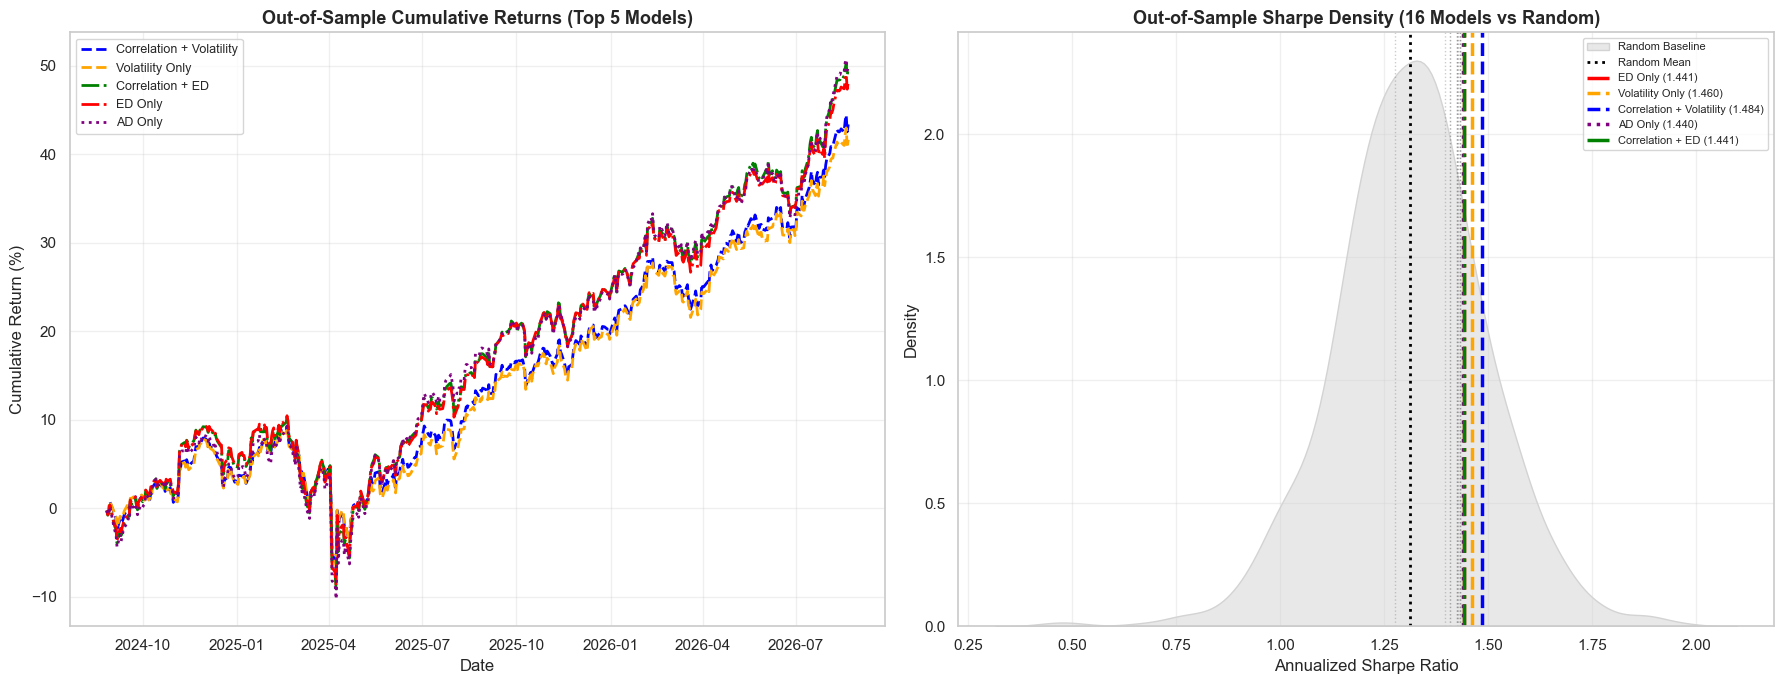

In [5]:
# ==========================================
# PHASE 7: OUT-OF-SAMPLE BACKTEST (16 MODELS)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# ---------- Yardımcı fonksiyonlar (train verisi için) ----------
def apply_garch_filter(series):
    """AR(1)-GARCH(1,1) filter; başarısızsa Z-score fallback yapılmaz."""
    scaled = series * 100
    try:
        model = arch_model(scaled, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t')
        res = model.fit(disp='off', show_warning=False)
        if res.convergence_flag != 0: raise RuntimeError(f"Convergence flag={res.convergence_flag}")
        std_resid = res.std_resid.dropna()
        if len(std_resid) < 100 or not np.all(np.isfinite(std_resid)): raise RuntimeError("Invalid or insufficient residuals")
        return std_resid.values
    except Exception as e:
        raise RuntimeError(f"GARCH filtering failed for '{series.name}': {e}")

def calculate_l_moments(x):
    n = len(x)
    if n < 4: return np.nan, np.nan
    x_sorted = np.sort(x)
    i = np.arange(1, n + 1)
    b0 = np.mean(x_sorted)
    b1 = np.mean(x_sorted * ((i - 1) / (n - 1)))
    b2 = np.mean(x_sorted * ((i - 1) * (i - 2) / ((n - 1) * (n - 2))))
    b3 = np.mean(x_sorted * ((i - 1) * (i - 2) * (i - 3) / ((n - 1) * (n - 2) * (n - 3))))
    l2 = 2 * b1 - b0
    l3 = 6 * b2 - 6 * b1 + b0
    l4 = 20 * b3 - 30 * b2 + 12 * b1 - b0
    l_skewness = l3 / l2 if l2 > 0 else np.nan
    l_kurtosis = l4 / l2 if l2 > 0 else np.nan
    return l_skewness, l_kurtosis

def calculate_hill_estimator(data, threshold_percentile=95):
    data = np.array(data)
    threshold_right = np.percentile(data, threshold_percentile)
    right_tail = data[data > threshold_right]
    gamma_right = np.mean(np.log(right_tail / threshold_right)) if (len(right_tail) > 1 and threshold_right > 0) else np.nan
    tail_idx_r = 1 / gamma_right if gamma_right > 0 else np.nan

    data_inv = -data
    threshold_left = np.percentile(data_inv, threshold_percentile)
    left_tail = data_inv[data_inv > threshold_left]
    gamma_left = np.mean(np.log(left_tail / threshold_left)) if (len(left_tail) > 1 and threshold_left > 0) else np.nan
    tail_idx_l = 1 / gamma_left if gamma_left > 0 else np.nan
    return tail_idx_r, tail_idx_l

def calc_gof_metrics(s_raw, b_raw, s_garch, b_garch):
    min_len = min(len(s_garch), len(b_garch))
    s_std = s_garch[-min_len:]
    b_std = b_garch[-min_len:]
    s_raw_aligned = s_raw[-min_len:]
    b_raw_aligned = b_raw[-min_len:]

    corr = np.corrcoef(s_raw_aligned, b_raw_aligned)[0, 1]
    ann_vol = np.std(s_raw_aligned, ddof=1) * np.sqrt(252)

    lb_p = acorr_ljungbox(s_std, lags=[10], return_df=True).iloc[0,1] if len(s_std) > 10 else np.nan
    jb_p = stats.jarque_bera(s_std)[1]   # <-- EKLENDİ
    ks_p = stats.ks_2samp(s_std, b_std).pvalue
    cvm_p = stats.cramervonmises_2samp(s_std, b_std).pvalue
    try:
        ad_p = stats.anderson_ksamp([s_std, b_std], method=stats.PermutationMethod(n_resamples=1000, random_state=42)).pvalue
    except:
        ad_p = stats.anderson_ksamp([s_std, b_std]).pvalue
    try:
        es_p = stats.epps_singleton_2samp(s_std, b_std)[1]
    except:
        es_p = np.nan

    ed_shape = stats.energy_distance(s_std, b_std)
    ed_total = stats.energy_distance(s_raw_aligned, b_raw_aligned)

    # 10 değer dönüyor
    return corr, ann_vol, lb_p, jb_p, ks_p, ad_p, cvm_p, es_p, ed_total, ed_shape


# ---------- Ana backtest fonksiyonu ----------
def run_phase7_oos_backtest(data_path, mapping_path, train_years=3, num_portfolios=1000):
    """
    16 modelin out-of-sample backtest'ini yapar.
    Modeller:
    1. ED Only
    2. ED + KS
    3. ED + KS + L-Kurt
    4. ED + KS + Tail_Asym
    5. ED + AD + Tail_Asym
    6. ED + AD + L-Kurt
    7. ED + CvM + Tail_Asym
    8. ED + Epps-Singleton + Tail_Asym
    9. Correlation Only
    10. Volatility Only
    11. Correlation + Volatility
    12. KS Only
    13. AD Only
    14. Correlation + ED
    15. Correlation + KS
    16. Correlation + ED + KS
    """
    print("\n" + "="*80)
    print(f"PHASE 7: OUT-OF-SAMPLE BACKTEST (16 MODELS | {train_years}Y Train)")
    print("="*80)

    # ---- 1. Veri yükleme ve train/test bölme ----
    returns_full = pd.read_csv(data_path, index_col=0, parse_dates=True)
    returns_full = np.log(returns_full / returns_full.shift(1)).dropna()
    mapping = pd.read_csv(mapping_path)

    train_days = int(train_years * 252)
    if len(returns_full) <= train_days:
        raise ValueError(f"Veri uzunluğu ({len(returns_full)} gün) Train süresi ({train_days} gün) için yetersiz!")

    train_returns = returns_full.iloc[:train_days]
    test_returns = returns_full.iloc[train_days:]

    stocks = mapping['Stock'].tolist()
    sector_dict = dict(zip(mapping['Stock'], mapping['Sector_ETF']))
    test_stock_returns = np.exp(test_returns[stocks].copy()) - 1   # basit getiri

    print(f"Train Periyodu: {train_returns.index[0].date()} -> {train_returns.index[-1].date()} ({len(train_returns)} gün)")
    print(f"Test Periyodu : {test_returns.index[0].date()} -> {test_returns.index[-1].date()} ({len(test_returns)} gün)")
    print("-" * 80)

    # ---- 2. Train verisi üzerinde metrik hesaplama ----
    print("Train verisi üzerinde GARCH ve metrik hesaplamaları yapılıyor...")
    train_residuals = {}
    for col in train_returns.columns:
        train_residuals[col] = apply_garch_filter(train_returns[col])

    metrics_train = []
    for stock in stocks:
        sector = sector_dict[stock]
        if sector not in train_returns.columns or stock not in train_returns.columns:
            continue
        s_raw = train_returns[stock].values
        b_raw = train_returns[sector].values
        s_res = train_residuals[stock]
        b_res = train_residuals[sector]

        corr, ann_vol, lb_p, jb_p, ks_p, ad_p, cvm_p, es_p, ed_total, ed_shape = calc_gof_metrics(
            s_raw, b_raw, s_res, b_res
        )
        _, l_kurt = calculate_l_moments(s_res)
        tail_idx_r, tail_idx_l = calculate_hill_estimator(s_res, 95)
        tail_asym = tail_idx_l / tail_idx_r if (pd.notna(tail_idx_l) and pd.notna(tail_idx_r)) else np.nan

        metrics_train.append({
            'Stock': stock,
            'Corr': corr,
            'Ann_Vol': ann_vol,
            'ED_Shape': ed_shape,
            'KS_p': ks_p,
            'AD_p': ad_p,
            'CvM_p': cvm_p,
            'ES_p': es_p if pd.notna(es_p) else 0.001,
            'L_Kurt': l_kurt if pd.notna(l_kurt) else 1.0,
            'Tail_Asym': tail_asym if pd.notna(tail_asym) else 1.0
        })

    df_train = pd.DataFrame(metrics_train).set_index('Stock').loc[stocks]
    ed_values = df_train['ED_Shape'].values
    ks_p_values = df_train['KS_p'].values
    ad_p_values = df_train['AD_p'].values
    cvm_p_values = df_train['CvM_p'].values
    es_p_values = df_train['ES_p'].values
    l_kurt_values = df_train['L_Kurt'].values
    tail_asym_values = df_train['Tail_Asym'].values
    corr_values = np.abs(df_train['Corr'].values)
    ann_vol_values = df_train['Ann_Vol'].values

    # ---- 3. 16 model ağırlığını hesapla ----
    model_configs = [
        {'name': 'ED Only', 'weights': 1.0 / ed_values},
        {'name': 'ED + KS', 'weights': (1.0 / ed_values) * (ks_p_values + 0.001)},
        {'name': 'ED + KS + L-Kurt', 'weights': ((1.0 / ed_values) * (ks_p_values + 0.001)) / l_kurt_values},
        {'name': 'ED + KS + Tail_Asym', 'weights': ((1.0 / ed_values) * (ks_p_values + 0.001)) * tail_asym_values},
        {'name': 'ED + AD + Tail_Asym', 'weights': ((1.0 / ed_values) * (ad_p_values + 0.001)) * tail_asym_values},
        {'name': 'ED + AD + L-Kurt', 'weights': ((1.0 / ed_values) * (ad_p_values + 0.001)) / l_kurt_values},
        {'name': 'ED + CvM + Tail_Asym', 'weights': ((1.0 / ed_values) * (cvm_p_values + 0.001)) * tail_asym_values},
        {'name': 'ED + Epps-Singleton + Tail_Asym', 'weights': ((1.0 / ed_values) * (es_p_values + 0.001)) * tail_asym_values},
        {'name': 'Correlation Only', 'weights': corr_values},
        {'name': 'Volatility Only', 'weights': 1.0 / (ann_vol_values + 0.001)},
        {'name': 'Correlation + Volatility', 'weights': corr_values / (ann_vol_values + 0.001)},
        {'name': 'KS Only', 'weights': ks_p_values + 0.001},
        {'name': 'AD Only', 'weights': ad_p_values + 0.001},
        {'name': 'Correlation + ED', 'weights': corr_values / ed_values},
        {'name': 'Correlation + KS', 'weights': corr_values * (ks_p_values + 0.001)},
        {'name': 'Correlation + ED + KS', 'weights': corr_values * (1.0 / ed_values) * (ks_p_values + 0.001)}
    ]

    # Ağırlıkları normalize et
    for cfg in model_configs:
        w = cfg['weights']
        w = np.nan_to_num(w, nan=1e-6, posinf=1e-6, neginf=1e-6)
        w = np.maximum(w, 1e-6)
        cfg['weights'] = w / np.sum(w)

    model_names = [cfg['name'] for cfg in model_configs]
    weights_list = [cfg['weights'] for cfg in model_configs]

    # ---- 4. Test performansı ----
    def calc_sharpe(w):
        port_ret = test_stock_returns.dot(w)
        return (port_ret.mean() / port_ret.std()) * np.sqrt(252) if port_ret.std() > 0 else 0

    def calc_es(w, alpha=0.05):
        port_ret = test_stock_returns.dot(w)
        threshold = np.percentile(port_ret, alpha * 100)
        return port_ret[port_ret <= threshold].mean() * 100

    # Monte Carlo rastgele portföyler (test dönemi)
    np.random.seed(42)
    random_sharpes = np.array([
        calc_sharpe(np.random.dirichlet(np.ones(len(stocks))))
        for _ in range(num_portfolios)
    ])
    random_mean = random_sharpes.mean()

    results = []
    for name, w in zip(model_names, weights_list):
        sharpe = calc_sharpe(w)
        es = calc_es(w)
        beat = np.sum(sharpe > random_sharpes) / num_portfolios * 100
        results.append({
            'Model': name,
            'OOS_Sharpe': sharpe,
            'OOS_Beat_Rate_%': beat,
            'OOS_Expected_Shortfall_%': es
        })

    df_results = pd.DataFrame(results).round(4)

    # ---- 5. Raporlama ----
    print(f"\nOOS Random Portfolios Mean Sharpe : {random_mean:.3f}")
    print("-" * 85)
    for _, row in df_results.iterrows():
        print(f"{row['Model']:35} -> OOS Sharpe: {row['OOS_Sharpe']:.4f} (Beats {row['OOS_Beat_Rate_%']:.1f}%) | OOS ES: {row['OOS_Expected_Shortfall_%']:.2f}%")

    # ---- 6. Tablo (tüm 16 model) ----
    print("\nSummary Table (16 Models):")
    print(df_results.to_markdown(index=False))
    df_results.to_csv("phase7_oos_16models_results.csv", index=False)

    # ---- 7. Grafik: En iyi 5 model (Sharpe'a göre) + Random ----
    top5 = df_results.nlargest(5, 'OOS_Sharpe')
    top5_names = top5['Model'].tolist()

    # Top-5 modellerin OOS cumulative returns serilerini kaydet
    cum_returns = {}
    for name in top5_names:
        w = weights_list[model_names.index(name)]
        port_ret = test_stock_returns.dot(w)
        cum_returns[name] = ((1 + port_ret).cumprod() - 1) * 100
    
    cum_returns_df = pd.DataFrame(cum_returns)
    cum_returns_df.index.name = 'Date'
    cum_returns_df.to_csv('phase7_oos_cumulative_returns_top5.csv')

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.set_theme(style="whitegrid")

    colors = ['blue', 'orange', 'green', 'red', 'purple', 'lightgray']
    linestyles = ['--', '--', '-.', '-.', ':', (0, (3, 1, 1, 1))]

    # Panel A: Kumulatif getiriler (en iyi 5 model)
    for idx, name in enumerate(top5_names):
        w = weights_list[model_names.index(name)]
        port_ret = test_stock_returns.dot(w)
        cum_ret = (1 + port_ret).cumprod() - 1
        axes[0].plot(cum_ret.index, cum_ret.values * 100,
                    label=name, color=colors[idx], linestyle=linestyles[idx], linewidth=2)

    axes[0].set_title('Out-of-Sample Cumulative Returns (Top 5 Models)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Cumulative Return (%)')
    axes[0].legend(loc='upper left', fontsize=9)
    axes[0].grid(alpha=0.3)

    # Panel B: Sharpe dağılımı (tüm modeller + random)
    sns.kdeplot(random_sharpes, fill=True, color='lightgray', alpha=0.5, ax=axes[1], label='Random Baseline')
    axes[1].axvline(random_mean, color='black', linestyle=':', linewidth=2, label='Random Mean')

    # Tüm modelleri çiz (renkleri daha soluk, küçük çizgi)
    for i, row in df_results.iterrows():
        if row['Model'] in top5_names:
            idx = top5_names.index(row['Model'])
            axes[1].axvline(row['OOS_Sharpe'], color=colors[idx], linestyle=linestyles[idx],
                            linewidth=2.5, label=f"{row['Model']} ({row['OOS_Sharpe']:.3f})")
        else:
            axes[1].axvline(row['OOS_Sharpe'], color='gray', linestyle=':', alpha=0.4, linewidth=1)

    axes[1].set_title('Out-of-Sample Sharpe Density (16 Models vs Random)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Annualized Sharpe Ratio')
    axes[1].set_ylabel('Density')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('phase7_oos_backtest_16models_top5.png', dpi=300, bbox_inches='tight')
    plt.show()

    return df_results, random_sharpes


# ==========================================
# ÇALIŞTIRMA BLOĞU
# ==========================================
if __name__ == "__main__":
    results_df, random_sharpes = run_phase7_oos_backtest(
        data_path="market_sector_data.csv",
        mapping_path="sector_mapping.csv",
        train_years=3,
        num_portfolios=1000
    )

In [ ]:
faz-8

In [ ]:
# ==========================================
# PHASE 8: ROLLING WINDOW FORECAST BACKTEST (3 SCENARIOS)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# ---------- Yardımcı Fonksiyonlar ----------
def apply_garch_filter(series):
    """
    AR(1)-GARCH(1,1) filter; başarısızsa None döner (pencere atlanır).
    """
    scaled = series * 100
    try:
        model = arch_model(scaled, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t')
        res = model.fit(disp='off', show_warning=False)
        if res.convergence_flag != 0:
            return None
        std_resid = res.std_resid.dropna()
        if len(std_resid) < 100 or not np.all(np.isfinite(std_resid)):
            return None
        return std_resid.values
    except Exception:
        return None

def calculate_l_moments(x):
    n = len(x)
    if n < 4: return np.nan, np.nan
    x_sorted = np.sort(x)
    i = np.arange(1, n + 1)
    b0 = np.mean(x_sorted)
    b1 = np.mean(x_sorted * ((i - 1) / (n - 1)))
    b2 = np.mean(x_sorted * ((i - 1) * (i - 2) / ((n - 1) * (n - 2))))
    b3 = np.mean(x_sorted * ((i - 1) * (i - 2) * (i - 3) / ((n - 1) * (n - 2) * (n - 3))))
    l2 = 2 * b1 - b0
    l3 = 6 * b2 - 6 * b1 + b0
    l4 = 20 * b3 - 30 * b2 + 12 * b1 - b0
    l_skewness = l3 / l2 if l2 > 0 else np.nan
    l_kurtosis = l4 / l2 if l2 > 0 else np.nan
    return l_skewness, l_kurtosis

def calculate_hill_estimator(data, threshold_percentile=90):
    """Hill Estimator with 90% threshold for 6-month windows."""
    data = np.array(data)
    threshold_right = np.percentile(data, threshold_percentile)
    right_tail = data[data > threshold_right]
    gamma_right = np.mean(np.log(right_tail / threshold_right)) if (len(right_tail) > 1 and threshold_right > 0) else np.nan
    tail_idx_r = 1 / gamma_right if gamma_right > 0 else np.nan

    data_inv = -data
    threshold_left = np.percentile(data_inv, threshold_percentile)
    left_tail = data_inv[data_inv > threshold_left]
    gamma_left = np.mean(np.log(left_tail / threshold_left)) if (len(left_tail) > 1 and threshold_left > 0) else np.nan
    tail_idx_l = 1 / gamma_left if gamma_left > 0 else np.nan
    return tail_idx_r, tail_idx_l

def calc_gof_metrics(s_raw, b_raw, s_garch, b_garch):
    min_len = min(len(s_garch), len(b_garch))
    s_std = s_garch[-min_len:]
    b_std = b_garch[-min_len:]
    s_raw_aligned = s_raw[-min_len:]
    b_raw_aligned = b_raw[-min_len:]

    corr = np.corrcoef(s_raw_aligned, b_raw_aligned)[0, 1]
    ann_vol = np.std(s_raw_aligned, ddof=1) * np.sqrt(252)
    lb_p = acorr_ljungbox(s_std, lags=[10], return_df=True).iloc[0,1] if len(s_std) > 10 else np.nan
    jb_p = stats.jarque_bera(s_std)[1]   # <-- EKLENDİ
    ks_p = stats.ks_2samp(s_std, b_std).pvalue
    cvm_p = stats.cramervonmises_2samp(s_std, b_std).pvalue
    
    try:
        ad_p = stats.anderson_ksamp([s_std, b_std], method=stats.PermutationMethod(n_resamples=1000, random_state=42)).pvalue
    except:
        try: ad_p = stats.anderson_ksamp([s_std, b_std]).pvalue
        except: ad_p = np.nan
        
    try: es_p = stats.epps_singleton_2samp(s_std, b_std)[1]
    except: es_p = np.nan

    ed_shape = stats.energy_distance(s_std, b_std)
    ed_total = stats.energy_distance(s_raw_aligned, b_raw_aligned)

    # 10 değer dönüyor
    return corr, ann_vol, lb_p, jb_p, ks_p, ad_p, cvm_p, es_p, ed_total, ed_shape

# ---------- Tek Bir Senaryo için Rolling Window Backtest ----------
def run_single_scenario_rolling(returns_full, mapping, stocks, sector_dict,
                                train_days=126, step_days=21, num_portfolios=1000,
                                scenario='garch'):
    """
    Tek bir senaryo (garch, zscore, raw) için rolling window backtest çalıştırır.
    Random portföyler her pencerede yeniden üretilir (dinamik baseline).
    """
    simple_returns_full = np.exp(returns_full[stocks].copy()) - 1
    total_days = len(returns_full)
    
    model_names = [
        'ED Only', 'ED + KS', 'ED + KS + L-Kurt', 'ED + KS + Tail_Asym', 
        'ED + AD + Tail_Asym', 'ED + AD + L-Kurt', 'ED + CvM + Tail_Asym', 
        'ED + Epps-Singleton + Tail_Asym', 'Correlation Only', 'Volatility Only', 
        'Correlation + Volatility', 'KS Only', 'AD Only', 'Correlation + ED', 
        'Correlation + KS', 'Correlation + ED + KS'
    ]
    
    # AĞIRLIK TAKİBİ İÇİN EKLENEN SÖZLÜK
    weight_history = {name: [] for name in model_names}
    
    # Modeller için OOS getirileri
    oos_portfolio_returns = {name: [] for name in model_names}
    oos_dates = []
    
    # Random portföyler için tüm OOS getirileri (num_portfolios kadar)
    random_portfolio_returns = [[] for _ in range(num_portfolios)]

    for t in range(train_days, total_days, step_days):
        end_idx = min(t + step_days, total_days)
        
        train_returns = returns_full.iloc[t - train_days : t]
        test_simple_returns = simple_returns_full.iloc[t : end_idx][stocks]  # Boyut eşleşmesi için [stocks] eklendi
        
        test_dates = test_simple_returns.index
        
        # ---- Senaryoya göre train verisini dönüştür ----
        if scenario == 'garch':
            train_residuals = {}
            garch_failed = False
            for col in train_returns.columns:
                resid = apply_garch_filter(train_returns[col])
                if resid is None:
                    print(f"  ⚠️ GARCH failed for {col} at window {t} (dates: {train_returns.index[0].date()} - {train_returns.index[-1].date()}), skipping this window.")
                    garch_failed = True
                    break
                train_residuals[col] = resid
            if garch_failed:
                continue
        elif scenario == 'zscore':
            train_residuals = {}
            for col in train_returns.columns:
                s = train_returns[col].values
                train_residuals[col] = (s - s.mean()) / s.std()
        else:  # raw
            train_residuals = {}
            for col in train_returns.columns:
                train_residuals[col] = train_returns[col].values

        # ---- Modeller için metrikleri hesapla ----
        metrics_train = []
        for stock in stocks:
            sector = sector_dict.get(stock)
            if sector not in train_returns.columns or stock not in train_returns.columns:
                continue
            
            s_raw = train_returns[stock].values
            b_raw = train_returns[sector].values
            s_res = train_residuals[stock]
            b_res = train_residuals[sector]

            corr, ann_vol, _, _, ks_p, ad_p, cvm_p, es_p, _, ed_shape = calc_gof_metrics(s_raw, b_raw, s_res, b_res)
            _, l_kurt = calculate_l_moments(s_res)
            tail_idx_r, tail_idx_l = calculate_hill_estimator(s_res, 90)
            tail_asym = tail_idx_l / tail_idx_r if (pd.notna(tail_idx_l) and pd.notna(tail_idx_r)) else np.nan

            metrics_train.append({
                'Stock': stock, 'Corr': corr, 'Ann_Vol': ann_vol, 'ED_Shape': ed_shape,
                'KS_p': ks_p, 'AD_p': ad_p, 'CvM_p': cvm_p, 'ES_p': es_p if pd.notna(es_p) else 0.001,
                'L_Kurt': l_kurt if pd.notna(l_kurt) else 1.0, 'Tail_Asym': tail_asym if pd.notna(tail_asym) else 1.0
            })

        # KeyError önlemek için .loc yerine .reindex kullanıldı
        df_train = pd.DataFrame(metrics_train).set_index('Stock').reindex(stocks)
        
        ed = df_train['ED_Shape'].values
        ks = df_train['KS_p'].values + 0.001
        ad = df_train['AD_p'].values + 0.001
        cvm = df_train['CvM_p'].values + 0.001
        es_p = df_train['ES_p'].values + 0.001
        lk = df_train['L_Kurt'].values
        ta = df_train['Tail_Asym'].values
        co = np.abs(df_train['Corr'].values)
        vo = df_train['Ann_Vol'].values + 0.001

        weights_dict = {
            'ED Only': 1.0 / ed,
            'ED + KS': (1.0 / ed) * ks,
            'ED + KS + L-Kurt': ((1.0 / ed) * ks) / lk,
            'ED + KS + Tail_Asym': ((1.0 / ed) * ks) * ta,
            'ED + AD + Tail_Asym': ((1.0 / ed) * ad) * ta,
            'ED + AD + L-Kurt': ((1.0 / ed) * ad) / lk,
            'ED + CvM + Tail_Asym': ((1.0 / ed) * cvm) * ta,
            'ED + Epps-Singleton + Tail_Asym': ((1.0 / ed) * es_p) * ta,
            'Correlation Only': co,
            'Volatility Only': 1.0 / vo,
            'Correlation + Volatility': co / vo,
            'KS Only': ks,
            'AD Only': ad,
            'Correlation + ED': co / ed,
            'Correlation + KS': co * ks,
            'Correlation + ED + KS': co * (1.0 / ed) * ks
        }

        # ---- Modelleri test et ----
        for name in model_names:
            w = weights_dict[name]
            w = np.nan_to_num(w, nan=1e-6, posinf=1e-6, neginf=1e-6)
            w = np.maximum(w, 1e-6)
            w = w / np.sum(w)
            
            # AĞIRLIKLARI KAYDET
            weight_history[name].append(w)
            
            period_returns = test_simple_returns.dot(w)
            oos_portfolio_returns[name].extend(period_returns.values)
            
        oos_dates.extend(test_dates)

        # ---- RANDOM PORTFÖYLER: HER PENCEREDE YENİ AĞIRLIKLAR ----
        np.random.seed(42 + t)
        for i in range(num_portfolios):
            rand_w = np.random.dirichlet(np.ones(len(stocks)))
            period_ret = test_simple_returns.dot(rand_w)
            random_portfolio_returns[i].extend(period_ret.values)

    # ---- Model sonuçlarını DataFrame'e çevir ----
    df_oos_returns = pd.DataFrame(oos_portfolio_returns, index=oos_dates)
    
    # ---- Random portföylerin Sharpe oranlarını hesapla ----
    random_sharpes = []
    for ret_series in random_portfolio_returns:
        rets = np.array(ret_series)
        sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() > 0 else 0
        random_sharpes.append(sharpe)
    random_sharpes = np.array(random_sharpes)
    random_mean = random_sharpes.mean()

    # ---- Model metrikleri ----
    results = []
    for name in model_names:
        rets = df_oos_returns[name]
        sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() > 0 else 0
        threshold = np.percentile(rets, 5)
        es = rets[rets <= threshold].mean() * 100
        beat = np.sum(sharpe > random_sharpes) / num_portfolios * 100
        
        results.append({
            'Model': name, 
            'OOS_Sharpe': sharpe, 
            'Beat_%': beat, 
            'ES_%': es
        })

    df_results = pd.DataFrame(results).round(4)
    
    # EKLENEN KISIM: Ağırlıkların ortalamasını al DataFrame yap
    avg_weights = {name: np.mean(weight_history[name], axis=0) for name in model_names}
    df_avg_weights = pd.DataFrame(avg_weights, index=stocks)
    
    # 5 DEĞİŞKEN DÖNDÜRÜYORUZ
    return df_results, df_oos_returns, random_sharpes, random_mean, df_avg_weights

# ---------- Ana Phase 8 Fonksiyonu (3 Senaryo) ----------
def run_phase8_rolling_backtest(data_path, mapping_path, 
                                train_days=126, step_days=21, 
                                num_portfolios=1000):
    """
    Phase 8: 3 senaryolu (GARCH, Z-score, Raw) Rolling Window Backtest.
    - Orijinal Panel A (Cum. Returns) ve Panel B (Sharpe Density) yapısı aynen korundu.
    - 3 senaryonun grafikleri 3x2 düzeninde tek bir görselde birleştirildi.
    - Kümülatif getiri ve PORTFÖY AĞIRLIKLARI CSV olarak kaydedildi.
    """
    print("\n" + "="*80)
    print("PHASE 8: ROLLING WINDOW FORECAST BACKTEST (3 SCENARIOS)")
    print(f"Train: {train_days} days | Forecast: {step_days} days | Hill: 90% threshold")
    print("="*80)

    # ---- Veri yükleme ----
    returns_full = pd.read_csv(data_path, index_col=0, parse_dates=True)
    returns_full = np.log(returns_full / returns_full.shift(1)).dropna()
    mapping = pd.read_csv(mapping_path)
    
    stocks = mapping['Stock'].tolist()
    sector_dict = dict(zip(mapping['Stock'], mapping['Sector_ETF']))
    
    total_days = len(returns_full)
    if total_days <= train_days:
        raise ValueError(f"Veri seti ({total_days} gün) eğitim penceresinden ({train_days} gün) kısa!")

    # ---- 3 senaryoyu çalıştır ----
    scenarios = ['garch', 'zscore', 'raw']
    scenario_labels = {
        'garch': 'ARMA-GARCH',
        'zscore': 'Z-Score',
        'raw': 'Raw'
    }
    
    all_results = {}
    all_returns = {}
    all_random = {}
    all_random_mean = {}
    all_weights = {}  # EKLENDİ

    for scenario in scenarios:
        print(f"\n--- Running Scenario: {scenario_labels[scenario]} ---")
        
        # 5 değişkeni yakala
        df_res, df_ret, rand_sharpes, rand_mean, df_avg_weights = run_single_scenario_rolling(
            returns_full, mapping, stocks, sector_dict,
            train_days, step_days, num_portfolios, scenario
        )
        all_results[scenario] = df_res
        all_returns[scenario] = df_ret
        all_random[scenario] = rand_sharpes
        all_random_mean[scenario] = rand_mean
        all_weights[scenario] = df_avg_weights  # Ağırlıkları kaydet

        print(f"Random Mean Sharpe: {rand_mean:.3f}")
        top3 = df_res.nlargest(3, 'OOS_Sharpe')
        for _, row in top3.iterrows():
            print(f"  {row['Model']:30} -> Sharpe: {row['OOS_Sharpe']:.4f} (Beat: {row['Beat_%']:.1f}%)")
        
        # O SENARYONUN AĞIRLIKLARINI CSV YAP
        weight_filename = f"phase8_avg_weights_{scenario}.csv"
        df_avg_weights.to_csv(weight_filename)
        print(f"  [Ağırlıklar kaydedildi: {weight_filename}]")

    # ---- Karşılaştırmalı Tablo (TÜM MODELLER) ----
    comparison_list = []
    for scenario in scenarios:
        df = all_results[scenario]
        for _, row in df.iterrows():
            comparison_list.append({
                'Model': row['Model'],
                'Scenario': scenario_labels[scenario],
                'OOS_Sharpe': row['OOS_Sharpe'],
                'Beat_%': row['Beat_%'],
                'ES_%': row['ES_%']
            })
    
    df_comp_all = pd.DataFrame(comparison_list)
    df_pivot_sharpe = df_comp_all.pivot(index='Model', columns='Scenario', values='OOS_Sharpe')
    df_pivot_beat = df_comp_all.pivot(index='Model', columns='Scenario', values='Beat_%')
    df_pivot_es = df_comp_all.pivot(index='Model', columns='Scenario', values='ES_%')
    
    df_pivot_sharpe.columns = [f'Sharpe_{col}' for col in df_pivot_sharpe.columns]
    df_pivot_beat.columns = [f'Beat_{col}' for col in df_pivot_beat.columns]
    df_pivot_es.columns = [f'ES_{col}' for col in df_pivot_es.columns]
    
    df_comparison = pd.concat([df_pivot_sharpe, df_pivot_beat, df_pivot_es], axis=1)
    
    new_order = []
    for model in df_comparison.index:
        row = [model]
        for scenario in ['ARMA-GARCH', 'Z-Score', 'Raw']:
            row.append(df_comparison.loc[model, f'Sharpe_{scenario}'])
            row.append(df_comparison.loc[model, f'Beat_{scenario}'])
            row.append(df_comparison.loc[model, f'ES_{scenario}'])
        new_order.append(row)
    
    columns_new = ['Model'] + [f'{s}_{m}' for s in ['ARMA-GARCH', 'Z-Score', 'Raw'] for m in ['Sharpe', 'Beat%', 'ES%']]
    df_final = pd.DataFrame(new_order, columns=columns_new).round(4)
    
    print("\n" + "="*80)
    print("COMPARISON TABLE (All Models across 3 Scenarios)")
    print("="*80)
    print(df_final.to_markdown(index=False))

    # ---- KÜMÜLATİF GETİRİ VERİLERİNİ CSV'YE KAYDETME ----
    cum_returns_all_scenarios = pd.DataFrame()
    for scenario in scenarios:
        df_ret = all_returns[scenario]
        cum_ret_df = (1 + df_ret).cumprod() - 1
        cum_ret_df_prefixed = cum_ret_df.add_prefix(f"{scenario_labels[scenario]}_")
        cum_returns_all_scenarios = pd.concat([cum_returns_all_scenarios, cum_ret_df_prefixed], axis=1)

    cum_returns_all_scenarios.to_csv("phase8_rolling_cum_returns_all_scenarios.csv")

    # ---- BIRLEŞTIRILMIŞ GRAFİK (3 Senaryo x 2 Panel = 3x2 Subplot Grid) ----
    fig, axes = plt.subplots(3, 2, figsize=(18, 18))
    sns.set_theme(style="whitegrid")
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

    for idx, scenario in enumerate(scenarios):
        df_res = all_results[scenario]
        df_ret = all_returns[scenario]
        rand_sharpes = all_random[scenario]
        rand_mean = all_random_mean[scenario]
        
        top5 = df_res.nlargest(5, 'OOS_Sharpe')
        top5_names = top5['Model'].tolist()

        ax_cum = axes[idx, 0]
        ax_kde = axes[idx, 1]

        # Panel A: Kumulatif Getiriler
        for c_idx, name in enumerate(top5_names):
            cum_ret = (1 + df_ret[name]).cumprod() - 1
            ax_cum.plot(cum_ret.index, cum_ret.values * 100, 
                        label=name, color=colors[c_idx], linestyle=linestyles[c_idx], linewidth=2)

        ax_cum.set_title(f'Rolling Forecast Cumulative Returns (Top 5) - {scenario_labels[scenario]}', 
                         fontsize=13, fontweight='bold')
        ax_cum.set_ylabel('Cumulative Return (%)')
        ax_cum.set_xlabel('Date')
        ax_cum.legend(loc='upper left')
        ax_cum.grid(alpha=0.3)

        # Panel B: Sharpe Dağılımı
        sns.kdeplot(rand_sharpes, fill=True, color='lightgray', alpha=0.5, ax=ax_kde, label='Random Baseline')
        ax_kde.axvline(rand_mean, color='black', linestyle=':', linewidth=2, label=f'Random Mean ({rand_mean:.3f})')

        for i, row in df_res.iterrows():
            if row['Model'] in top5_names:
                m_idx = top5_names.index(row['Model'])
                ax_kde.axvline(row['OOS_Sharpe'], color=colors[m_idx], linestyle=linestyles[m_idx],
                               linewidth=2.5, label=f"{row['Model']} ({row['OOS_Sharpe']:.3f})")
            else:
                ax_kde.axvline(row['OOS_Sharpe'], color='gray', linestyle=':', alpha=0.3, linewidth=1)

        ax_kde.set_title(f'Rolling Forecast Sharpe Density - {scenario_labels[scenario]}', 
                         fontsize=13, fontweight='bold')
        ax_kde.set_xlabel('Annualized Sharpe Ratio')
        ax_kde.legend(loc='upper right', fontsize=8)
        ax_kde.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('phase8_rolling_forecast_combined.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---- Sonuçları kaydet ----
    df_final.to_csv("phase8_rolling_comparison_all_models.csv", index=False)
    
    print("\nPhase 8 tamamlandı! Bütün sonuçlar, kümülatif getiri CSV'si, Ağırlık CSV'leri ve birleştirilmiş görsel kaydedildi.")
    
    return all_results, all_returns, all_random, df_final, all_weights

# ==========================================
# ÇALIŞTIRMA BLOĞU
# ==========================================
if __name__ == "__main__":
    all_results, all_returns, all_random, df_comparison, all_weights = run_phase8_rolling_backtest(
        data_path="market_sector_data.csv",
        mapping_path="sector_mapping.csv",
        train_days=126,
        step_days=21,
        num_portfolios=1000
    )


PHASE 8: ROLLING WINDOW FORECAST BACKTEST (3 SCENARIOS)
Train: 126 days | Forecast: 21 days | Hill: 90% threshold

--- Running Scenario: ARMA-GARCH ---


Faz-9 validation and cross-check

In [7]:
# ==========================================
# PHASE 9: WEIGHT ALLOCATION & RISK PROFILE CROSS-CHECK
# ==========================================
import pandas as pd
import numpy as np

def run_phase9_weight_analysis():
    print("="*80)
    print("PHASE 9: PORTFOLIO WEIGHT & RISK PROFILE CROSS-VALIDATION")
    print("="*80)

    # 1. Dosyaları Oku (Phase 8'den kaydedilen CSV'ler)
    try:
        df_z = pd.read_csv('phase8_avg_weights_zscore.csv', index_col=0)
        df_r = pd.read_csv('phase8_avg_weights_raw.csv', index_col=0)
        df_g = pd.read_csv('phase8_avg_weights_garch.csv', index_col=0)
    except FileNotFoundError:
        print("Hata: Phase 8 ağırlık dosyaları bulunamadı. Lütfen önce Phase 8'i çalıştırın.")
        return

    # 2. Risk Gruplarını Tanımla (Faz 5 Clustering Sonuçlarına Göre)
    risk_mapping = {
        # Cluster 2: Low Distributional Risk
        'NVDA': 'Low Distributional Risk',
        'HD':   'Low Distributional Risk',
        'XOM':  'Low Distributional Risk',
        'COP':  'Low Distributional Risk',
        
        # Cluster 1: Intermediate Distributional Profile
        'AAPL': 'Intermediate Distributional Profile',
        'MSFT': 'Intermediate Distributional Profile',
        'TSLA': 'Intermediate Distributional Profile',
        'AMZN': 'Intermediate Distributional Profile',
        'JPM':  'Intermediate Distributional Profile',
        'BAC':  'Intermediate Distributional Profile',
        'GS':   'Intermediate Distributional Profile',
        'CVX':  'Intermediate Distributional Profile',
        'JNJ':  'Intermediate Distributional Profile',
        'PFE':  'Intermediate Distributional Profile',
        'PG':   'Intermediate Distributional Profile',
        'KO':   'Intermediate Distributional Profile',
        
        # Cluster 0: High Distributional Risk
        'UNH':  'High Distributional Risk',
        'WMT':  'High Distributional Risk'
    }

    stocks = df_z.index.tolist()
    num_stocks = len(stocks)
    equal_weight = 1.0 / num_stocks  # Eşit ağırlık baz çizgisi (1/18 = %5.56)

    # 3. Tüm senaryolardaki ve en iyi modeldeki ağırlıkları hesapla
    # Flagship (En İyi) Model
    best_model = 'ED + Epps-Singleton + Tail_Asym'
    
    analysis_data = []
    for stock in stocks:
        # Tüm Modellerin Tüm Senaryolardaki Ortalaması
        overall_avg = np.mean([
            df_z.loc[stock].mean(), 
            df_r.loc[stock].mean(), 
            df_g.loc[stock].mean()
        ])
        
        # Sadece En İyi Modelin (3 Senaryo) Ortalaması
        if best_model in df_z.columns:
            best_model_avg = np.mean([
                df_z.loc[stock, best_model],
                df_r.loc[stock, best_model],
                df_g.loc[stock, best_model]
            ])
        else:
            best_model_avg = np.nan
            
        risk_profile = risk_mapping.get(stock, 'Unknown')
        
        analysis_data.append({
            'Stock': stock,
            'Risk Profile': risk_profile,
            'Equal Weight (%)': equal_weight * 100,
            'Overall Avg Weight (%)': overall_avg * 100,
            'Best Model Weight (%)': best_model_avg * 100
        })

    df_analysis = pd.DataFrame(analysis_data)
    
    # 4. Risk Gruplarına Göre Özet Tablo
    group_summary = df_analysis.groupby('Risk Profile').agg(
        Count=('Stock', 'count'),
        Avg_Overall_Weight_Pct=('Overall Avg Weight (%)', 'mean'),
        Avg_Best_Model_Weight_Pct=('Best Model Weight (%)', 'mean')
    ).reset_index()

    # Baz çizgisine (Equal Weight) göre sapmayı hesapla
    group_summary['Deviation from Equal W. (%)'] = group_summary['Avg_Best_Model_Weight_Pct'] - (equal_weight * 100)

    # Risk Grubuna Göre Sıralama (Low -> Intermediate -> High)
    group_summary['Sort_Key'] = group_summary['Risk Profile'].map({
        'Low Distributional Risk': 1,
        'Intermediate Distributional Profile': 2,
        'High Distributional Risk': 3
    })
    group_summary = group_summary.sort_values('Sort_Key').drop(columns=['Sort_Key'])

    # 5. Sonuçları Ekrana Yazdır ve Kaydet
    print("\n--- HİSSE BAZINDA AĞIRLIK DOĞRULAMASI ---")
    df_sorted = df_analysis.sort_values(by='Best Model Weight (%)', ascending=False)
    print(df_sorted.round(2).to_markdown(index=False))

    print("\n--- RİSK PROFİLİNE GÖRE AĞIRLIK KÜMELEMESİ (CROSS-CHECK) ---")
    print(group_summary.round(2).to_markdown(index=False))
    print(f"\n* Note: Equal Weight Benchmark is {equal_weight*100:.2f}% per stock.")

    # CSV olarak kaydet
    df_sorted.to_csv('phase9_stock_weights_analysis.csv', index=False)
    group_summary.to_csv('phase9_risk_group_summary.csv', index=False)
    print("\nPhase 9 tamamlandı! Analiz tabloları CSV olarak kaydedildi.")
    
    return df_analysis, group_summary

if __name__ == "__main__":
    df_analysis, group_summary = run_phase9_weight_analysis()

PHASE 9: PORTFOLIO WEIGHT & RISK PROFILE CROSS-VALIDATION

--- HİSSE BAZINDA AĞIRLIK DOĞRULAMASI ---
| Stock   | Risk Profile                        |   Equal Weight (%) |   Overall Avg Weight (%) |   Best Model Weight (%) |
|:--------|:------------------------------------|-------------------:|-------------------------:|------------------------:|
| CVX     | Intermediate Distributional Profile |               5.56 |                     9.44 |                   11.57 |
| XOM     | Low Distributional Risk             |               5.56 |                     8.88 |                    9.39 |
| KO      | Intermediate Distributional Profile |               5.56 |                     8.17 |                    9.34 |
| AAPL    | Intermediate Distributional Profile |               5.56 |                     6.06 |                    7.49 |
| MSFT    | Intermediate Distributional Profile |               5.56 |                     6.26 |                    7.09 |
| COP     | Low Distributional 

In [ ]:
faz-10 


PHASE 10: TRANSACTION COST & TURNOVER ANALYSIS (3Y Train)
Train: 756 gün | Test: 498 gün (~2.0 yıl)
Train verisi üzerinde metrikler hesaplanıyor...

Portföyler değerlendiriliyor...

PHASE 10: TRANSACTION COST SENSITIVITY (16 Models)
| Model                           |   Gross Sharpe |   Annual Turnover |   Net Sharpe (25bp) |   Net Cum. Return (25bp) |   Net Sharpe (50bp) |   Net Cum. Return (50bp) |
|:--------------------------------|---------------:|------------------:|--------------------:|-------------------------:|--------------------:|-------------------------:|
| ED Only                         |         1.3125 |            0.0438 |              1.3118 |                  43.1902 |              1.311  |                  43.1592 |
| ED + KS                         |         1.341  |            0.0415 |              1.3403 |                  45.6525 |              1.3397 |                  45.6227 |
| ED + KS + L-Kurt                |         1.3349 |            0.0415 |          

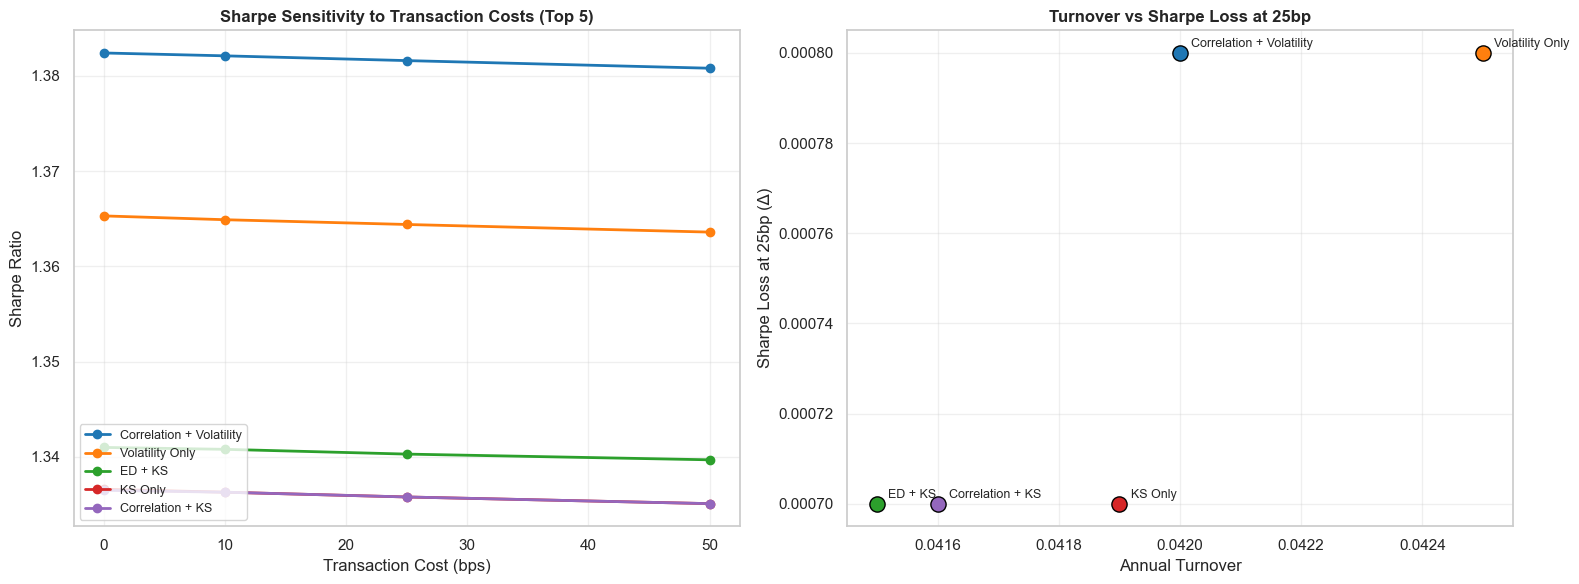


Phase 10 tamamlandı! Sonuçlar kaydedildi.


In [11]:
# ==========================================
# PHASE 10: PORTFOLIO IMPLEMENTATION ROBUSTNESS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---------- Turnover ve Drift Getirisi Hesaplama ----------
def compute_turnover_and_returns(test_returns_matrix, target_weights, rebalance_days):
    """
    Yıllık rebalancing altında:
    1. Günlük portfolio return
    2. Rebalancing kaynaklı turnover
    3. Portfolio weight drift

    Not:
    t=0 test başlangıcında hedef ağırlıklar zaten oluşturulduğu için
    herhangi bir initial transaction cost uygulanmaz.
    """
    T, N = test_returns_matrix.shape

    current_w = target_weights.copy()
    turnover_series = np.zeros(T)
    port_returns = np.zeros(T)

    for t in range(T):

        # Rebalancing: target weights'a dönüş
        if t in rebalance_days and t != 0:
            turnover_series[t] = (
                0.5 * np.sum(np.abs(target_weights - current_w))
            )
            current_w = target_weights.copy()

        # Günlük portföy getirisi
        r_t = np.sum(current_w * test_returns_matrix[t])
        port_returns[t] = r_t

        # Getiri sonrası ağırlık drift'i
        if r_t > -1.0:
            current_w = current_w * (1 + test_returns_matrix[t]) / (1 + r_t)
        else:
            current_w = np.zeros_like(current_w) # Portföy sıfırlandı

    return turnover_series.sum(), turnover_series, port_returns


# ---------- Ana Fonksiyon ----------
def run_phase10_portfolio_robustness(data_path, mapping_path,
                                      train_years=3,
                                      cost_levels=[0.0010, 0.0025, 0.0050],
                                      rebalance_period_days=252):
    """
    Phase 10: İşlem maliyeti ve turnover analizi.
        - Gross Sharpe, yıllık rebalancing simülasyonundan hesaplanır (drift dahil).
        - Turnover aynı simülasyondan elde edilir.
        - Net Sharpe = Gross Sharpe - (cost × annual_turnover / annual_vol).
        - Phase 7'deki sürekli rebalancing idealleştirmesinden farklı olarak, bu analiz
          gerçekçi yıllık rebalancing varsayımını kullanır.
    """
    print("\n" + "="*80)
    print(f"PHASE 10: TRANSACTION COST & TURNOVER ANALYSIS ({train_years}Y Train)")
    print("="*80)

    # ---- 1. Veri yükleme (Phase 7 ile birebir aynı) ----
    returns_full = pd.read_csv(data_path, index_col=0, parse_dates=True)
    returns_full = np.log(returns_full / returns_full.shift(1)).dropna()
    mapping = pd.read_csv(mapping_path)

    train_days = int(train_years * 252)
    if len(returns_full) <= train_days:
        raise ValueError("Veri yetersiz!")

    train_returns = returns_full.iloc[:train_days]
    test_returns  = returns_full.iloc[train_days:]

    stocks = mapping['Stock'].tolist()
    sector_dict = dict(zip(mapping['Stock'], mapping['Sector_ETF']))

    n_test_days = len(test_returns)
    n_test_years = n_test_days / 252

    print(f"Train: {len(train_returns)} gün | Test: {n_test_days} gün (~{n_test_years:.1f} yıl)")

    # ---- 2. Train metrikleri (Phase 7 ile aynı) ----
    print("Train verisi üzerinde metrikler hesaplanıyor...")
    train_residuals = {}
    for col in train_returns.columns:
        train_residuals[col] = apply_garch_filter(train_returns[col])

    metrics_train = []
    for stock in stocks:
        sector = sector_dict[stock]
        if sector not in train_returns.columns or stock not in train_returns.columns:
            continue

        s_raw = train_returns[stock].values
        b_raw = train_returns[sector].values
        s_res = train_residuals[stock]
        b_res = train_residuals[sector]

        corr, ann_vol, lb_p, jb_p, ks_p, ad_p, cvm_p, es_p, _, ed_shape = calc_gof_metrics(
            s_raw, b_raw, s_res, b_res
        )
        _, l_kurt = calculate_l_moments(s_res)
        tail_idx_r, tail_idx_l = calculate_hill_estimator(s_res, 95)   # 3-yıl → 95
        tail_asym = tail_idx_l / tail_idx_r if (pd.notna(tail_idx_l) and pd.notna(tail_idx_r)) else 1.0

        metrics_train.append({
            'Stock': stock, 'Corr': corr, 'Ann_Vol': ann_vol,
            'ED_Shape': ed_shape, 'KS_p': ks_p, 'AD_p': ad_p,
            'CvM_p': cvm_p, 'ES_p': es_p if pd.notna(es_p) else 0.001,
            'L_Kurt': l_kurt if pd.notna(l_kurt) else 1.0,
            'Tail_Asym': tail_asym if pd.notna(tail_asym) else 1.0
        })

    df_train = pd.DataFrame(metrics_train).set_index('Stock').loc[stocks]

    ed = df_train['ED_Shape'].values
    ks = df_train['KS_p'].values + 0.001
    ad = df_train['AD_p'].values + 0.001
    cvm = df_train['CvM_p'].values + 0.001
    es_p = df_train['ES_p'].values + 0.001
    lk = df_train['L_Kurt'].values
    ta = df_train['Tail_Asym'].values
    co = np.abs(df_train['Corr'].values)
    vo = df_train['Ann_Vol'].values + 0.001

    # ---- 3. 16 model ağırlığı (Phase 7 ile birebir) ----
    model_configs = {
        'ED Only':                          1.0 / ed,
        'ED + KS':                          (1.0 / ed) * ks,
        'ED + KS + L-Kurt':                 ((1.0 / ed) * ks) / lk,
        'ED + KS + Tail_Asym':              ((1.0 / ed) * ks) * ta,
        'ED + AD + Tail_Asym':              ((1.0 / ed) * ad) * ta,
        'ED + AD + L-Kurt':                 ((1.0 / ed) * ad) / lk,
        'ED + CvM + Tail_Asym':             ((1.0 / ed) * cvm) * ta,
        'ED + Epps-Singleton + Tail_Asym':  ((1.0 / ed) * es_p) * ta,
        'Correlation Only':                 co,
        'Volatility Only':                  1.0 / vo,
        'Correlation + Volatility':         co / vo,
        'KS Only':                          ks,
        'AD Only':                          ad,
        'Correlation + ED':                 co / ed,
        'Correlation + KS':                 co * ks,
        'Correlation + ED + KS':            co * (1.0 / ed) * ks
    }

    for name in model_configs:
        w = model_configs[name]
        w = np.nan_to_num(w, nan=1e-6, posinf=1e-6, neginf=1e-6)
        w = np.maximum(w, 1e-6)
        model_configs[name] = w / np.sum(w)

    # ---- 4. Test matrisi ----
    test_simple_matrix = (np.exp(test_returns[stocks].copy()) - 1).values
    #test_simple_df = test_returns[stocks].copy()
    #test_simple_df[:] = np.exp(test_simple_df.values) - 1

    # Yıllık yeniden dengeleme noktaları
    rebalance_days = list(range(0, n_test_days, rebalance_period_days))

    # ---- 5. Her model için analiz ----
    print("\nPortföyler değerlendiriliyor...")
    results = []

    for name, target_w in model_configs.items():

        # YENİ KOD: Hem turnover hem de drift'e maruz kalmış gerçek getiri serisi alınır
        total_turnover, turnover_series, port_ret_gross = compute_turnover_and_returns(
            test_simple_matrix, target_w, rebalance_days
        )
        
        annual_turnover = total_turnover / n_test_years
        
        gross_sharpe = (port_ret_gross.mean() / port_ret_gross.std(ddof=1)) * np.sqrt(252)
        gross_vol = port_ret_gross.std(ddof=1) * np.sqrt(252)
        
        # --- Net performance after transaction costs ---
        net_sharpes = {}
        net_cum_returns = {}
        
        for c in cost_levels:
            # Transaction cost is charged only when rebalancing occurs
            net_ret = (1 + port_ret_gross) * (1 - c * turnover_series) - 1
        
            # Net Sharpe based on the actual net return series
            net_sharpes[c] = (
                net_ret.mean() / net_ret.std(ddof=1)
            ) * np.sqrt(252)
        
            # Cumulative net return after transaction costs
            net_cum_returns[c] = np.prod(1 + net_ret) - 1

        # ... (Sözlüğe ekleme kısmı aynı kalacak) ...

        results.append({
            'Model': name,
            'Gross Sharpe': gross_sharpe,
            'Annual Turnover': annual_turnover,
            'Net Sharpe (10bp)': net_sharpes[cost_levels[0]],
            'Net Sharpe (25bp)': net_sharpes[cost_levels[1]],
            'Net Sharpe (50bp)': net_sharpes[cost_levels[2]],
            'Net Cum. Return (10bp)': net_cum_returns[cost_levels[0]] * 100,
            'Net Cum. Return (25bp)': net_cum_returns[cost_levels[1]] * 100,
            'Net Cum. Return (50bp)': net_cum_returns[cost_levels[2]] * 100,
            'Δ Sharpe (25bp)': gross_sharpe - net_sharpes[cost_levels[1]]
        })

    df_results = pd.DataFrame(results).round(4)

    # ---- 6. Raporlama ----
    print("\n" + "="*80)
    print("PHASE 10: TRANSACTION COST SENSITIVITY (16 Models)")
    print("="*80)
    cols_show = [
    'Model',
    'Gross Sharpe',
    'Annual Turnover',
    'Net Sharpe (25bp)',
    'Net Cum. Return (25bp)',
    'Net Sharpe (50bp)',
    'Net Cum. Return (50bp)']
    print(df_results[cols_show].to_markdown(index=False))

    # ---- 7. Görselleştirme ----
    top5 = df_results.nlargest(5, 'Gross Sharpe')['Model'].tolist()
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_theme(style="whitegrid")
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    # Panel A: Sharpe vs Cost
    for i, model in enumerate(top5):
        row = df_results[df_results['Model'] == model].iloc[0]
        sharpes = [row['Gross Sharpe'],
                   row['Net Sharpe (10bp)'],
                   row['Net Sharpe (25bp)'],
                   row['Net Sharpe (50bp)']]
        axes[0].plot([0, 10, 25, 50], sharpes, marker='o',
                     label=model, color=colors[i], linewidth=2)
    axes[0].set_xlabel('Transaction Cost (bps)')
    axes[0].set_ylabel('Sharpe Ratio')
    axes[0].set_title('Sharpe Sensitivity to Transaction Costs (Top 5)',
                      fontsize=12, fontweight='bold')
    axes[0].legend(loc='lower left', fontsize=9)
    axes[0].grid(alpha=0.3)

    # Panel B: Turnover vs Sharpe Loss
    for i, model in enumerate(top5):
        row = df_results[df_results['Model'] == model].iloc[0]
        axes[1].scatter(row['Annual Turnover'], row['Δ Sharpe (25bp)'],
                        s=120, color=colors[i], edgecolor='black', zorder=3)
        axes[1].annotate(model, (row['Annual Turnover'], row['Δ Sharpe (25bp)']),
                         textcoords="offset points", xytext=(8, 4), fontsize=9)
    axes[1].set_xlabel('Annual Turnover')
    axes[1].set_ylabel('Sharpe Loss at 25bp (Δ)')
    axes[1].set_title('Turnover vs Sharpe Loss at 25bp',
                      fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('phase10_transaction_costs.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ---- 8. CSV ----
    df_results.to_csv('phase10_transaction_cost_results.csv', index=False)
    print("\nPhase 10 tamamlandı! Sonuçlar kaydedildi.")

    return df_results


# ==========================================
# ÇALIŞTIRMA
# ==========================================
if __name__ == "__main__":
    df_phase10 = run_phase10_portfolio_robustness(
        data_path="market_sector_data.csv",
        mapping_path="sector_mapping.csv",
        train_years=3,
        cost_levels=[0.0010, 0.0025, 0.0050],
        rebalance_period_days=252
    )